##### conda activate thesis1

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))  # Adds project root

In [2]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statistics import mode
import folium
from folium.plugins import MarkerCluster
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import random
from sklearn.impute import SimpleImputer
from typing import Dict
import seaborn as sns
from sklearn.impute import SimpleImputer
from IPython.display import display, HTML
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings("ignore")

In [3]:
from typing import List, Tuple
from Algorithms.CDREC import CDRec
from Algorithms.TKCM import TKCM
from Algorithms.TKCM_Weighted import TKCM_Weighted
from Algorithms.DynaMMO import DynaMMo
from Algorithms.SoftImpute import SoftImpute
from Algorithms.SVDImpute import IterativeSVD
from Algorithms.trmf import TRMFImputer
from Algorithms.ST_MVL import ST_MVL
from Algorithms.TKCM_PLUS import TKCM_PLUS
from Algorithms.TKCM_PRO import TKCM_PRO


In [4]:

# # Load dataset
valley_df = pd.read_csv("D:\\Thesis\\Project\\Data\\valley_data.csv")

# Count different types of missingness
stats = {
    "Total Rows": len(valley_df),
    "Total Columns": len(valley_df.columns),
    "Zero Values": (valley_df == 0).sum().sum(),
    "NaN Values": valley_df.isna().sum().sum(),
    "Blank Strings": (valley_df == "").sum().sum(),
    "Unknown Strings": (valley_df.applymap(lambda x: isinstance(x, str) and x.strip().lower() == "unknown")).sum().sum()
}

# Return as DataFrame
stats_df = pd.DataFrame(list(stats.items()), columns=["Metric", "Value"])
stats_df


,Metric,Value
0,Total Rows,7079427
1,Total Columns,6
2,Zero Values,1667902
3,NaN Values,0
4,Blank Strings,0
5,Unknown Strings,0


In [5]:
df = valley_df.copy()

In [6]:
# Parse timestamp and do a quick check of frequency for one station/sensor
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
df["value"] = pd.to_numeric(df["value"], errors="coerce")
df["timestamp"].isna().mean(), df["value"].isna().mean(), df["timestamp"].min(), df["timestamp"].max()


(np.float64(0.0),
 np.float64(0.0),
 Timestamp('2023-01-01 00:00:00+0000', tz='UTC'),
 Timestamp('2025-01-01 00:00:00+0000', tz='UTC'))

In [7]:
# Determine typical sampling interval for a random station/sensor with enough points
sample_key = df.groupby(["station_code","sensor_code"]).size().sort_values(ascending=False).index[0]
sample = df[(df["station_code"]==sample_key[0]) & (df["sensor_code"]==sample_key[1])].sort_values("timestamp")
dt = sample["timestamp"].diff().dropna()
dt.value_counts().head(), dt.median()


(timestamp
 0 days 00:00:00      14591
 0 days 00:30:00      14587
 0 days 01:30:00          1
 217 days 00:30:00        1
 210 days 00:30:00        1
 Name: count, dtype: int64,
 Timedelta('0 days 00:00:00'))

In [8]:
path = "D:\\Thesis\\Project\\Data\\valley_data.csv"

In [9]:
df = pd.read_csv(path, usecols=["station_code","sensor_code","timestamp","value"])
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df["value"] = pd.to_numeric(df["value"], errors="coerce")

# Choose a station with many sensors/points (top by count)
station_counts = df.groupby("station_code").size().sort_values(ascending=False)
top_station = station_counts.index[0]
top_station, int(station_counts.iloc[0])

('74200MS', 141245)

In [10]:
station_df = df[df["station_code"]==top_station].copy()
station_df["sensor_code"].value_counts()


sensor_code
LT        14591
LF        14591
SD        14591
GS        14591
HS        14591
LD.RED    14591
WR        14590
WG.BOE    14590
WG        14590
N          9929
Name: count, dtype: int64

In [11]:
def seasonality_score(ts: pd.Series, freq="30min"):
    # aggregate duplicates and resample
    s = ts.groupby(ts.index).mean().to_frame("value").resample(freq).mean()["value"]
    x = s.to_numpy()
    # detrend with 7-day rolling mean
    roll = pd.Series(x).rolling(336, min_periods=100, center=True).mean().to_numpy()
    x_detr = x - roll
    def acf_lag(lag):
        if len(x_detr) <= lag + 10:
            return np.nan
        a = x_detr[:-lag]; b = x_detr[lag:]
        m = np.isfinite(a) & np.isfinite(b)
        if m.sum() < 50:
            return np.nan
        a = a[m]; b = b[m]
        if np.std(a)==0 or np.std(b)==0:
            return 0.0
        return float(np.corrcoef(a, b)[0,1])
    daily = abs(acf_lag(48))
    weekly = abs(acf_lag(336))
    return float(np.nanmax([daily, weekly])), float(daily), float(weekly)

scores = []
for sensor, g in station_df.groupby("sensor_code"):
    series = g.sort_values("timestamp").set_index("timestamp")["value"]
    sc, d, w = seasonality_score(series)
    scores.append((sensor, sc, d, w, len(series)))
score_df = pd.DataFrame(scores, columns=["sensor_code","seasonality_score","acf_daily","acf_weekly","n"]).sort_values("seasonality_score", ascending=False)
score_df


,sensor_code,seasonality_score,acf_daily,acf_weekly,n
0,GS,0.854969,0.854969,0.836793,14591
6,SD,0.678644,0.678644,0.637305,14591
4,LT,0.430231,0.430231,0.318199,14591
2,LD.RED,0.309701,0.309701,0.102571,14591
1,HS,0.268635,0.268635,0.062729,14591
3,LF,0.202465,0.202465,0.198608,14591
9,WR,0.064173,0.054409,0.064173,14590
8,WG.BOE,0.055921,0.032530,0.055921,14590
5,N,0.047755,0.047755,0.000317,9929
7,WG,0.042181,0.021588,0.042181,14590


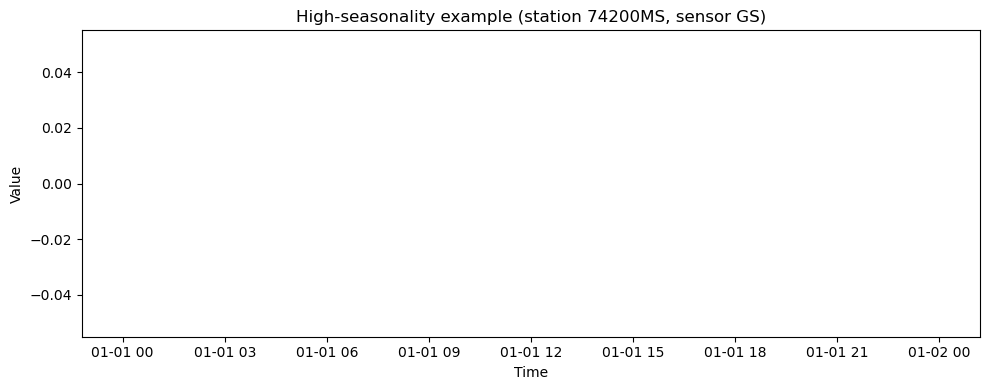

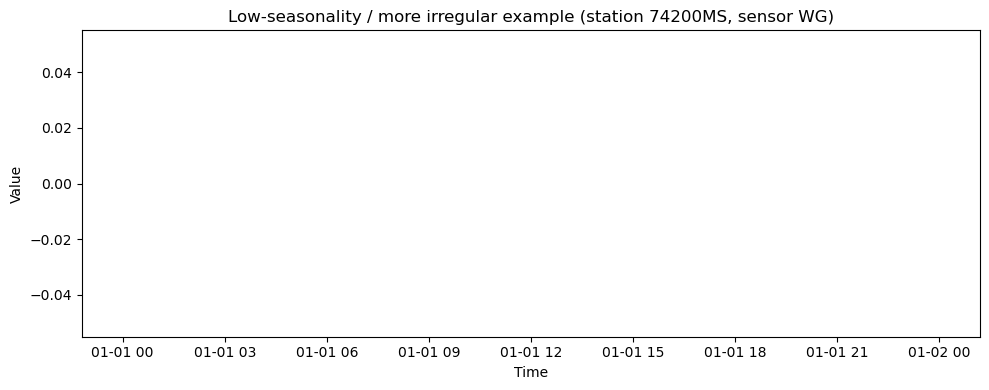

('high_seasonality.png', 'low_seasonality.png', 'GS', 'WG')

In [24]:
from pathlib import Path
# out_dir = Path("/data/ts_plots")
# out_dir.mkdir(exist_ok=True)

def get_series(station, sensor):
    g = df[(df["station_code"]==station) & (df["sensor_code"]==sensor)].copy()
    g = g.sort_values("timestamp").groupby("timestamp", as_index=True)["value"].mean()
    # resample 30min for smooth plotting
    g = g.resample("30min").mean()
    return g

station = top_station
seasonal_sensor = score_df.iloc[0]["sensor_code"]
normal_sensor = score_df.sort_values("seasonality_score").iloc[0]["sensor_code"]

seasonal = get_series(station, seasonal_sensor)
normal = get_series(station, normal_sensor)

# Focus on a 3-month window for readability (but still show seasonality); choose summer period 2024
start = pd.Timestamp("2024-06-01", tz="UTC")
end = pd.Timestamp("2024-09-01", tz="UTC")

seasonal_win = seasonal.loc[start:end]
normal_win = normal.loc[start:end]

# Plot 1: High seasonality
plt.figure(figsize=(10,4))
plt.plot(seasonal_win.index.tz_convert(None), seasonal_win.values)
plt.title(f"High-seasonality example (station {station}, sensor {seasonal_sensor})")
plt.xlabel("Time")
plt.ylabel("Value")
plt.tight_layout()

p1 =  "high_seasonality.png"
#plt.savefig(p1, dpi=200)
plt.show()

# Plot 2: Low seasonality (more 'normal'/irregular)
plt.figure(figsize=(10,4))
plt.plot(normal_win.index.tz_convert(None), normal_win.values)
plt.title(f"Low-seasonality / more irregular example (station {station}, sensor {normal_sensor})")
plt.xlabel("Time")
plt.ylabel("Value")
plt.tight_layout()
p2 = "low_seasonality.png"
#plt.savefig(p2, dpi=200)
plt.show()

str(p1), str(p2), seasonal_sensor, normal_sensor


In [25]:
seasonal_win.index.min(), seasonal_win.index.max(), len(seasonal_win), seasonal.index.min(), seasonal.index.max()


(Timestamp('2024-06-01 00:00:00+0000', tz='UTC'),
 Timestamp('2024-09-01 00:00:00+0000', tz='UTC'),
 4417,
 Timestamp('2023-01-01 00:00:00+0000', tz='UTC'),
 Timestamp('2025-01-01 00:00:00+0000', tz='UTC'))

In [26]:
seasonal_win.isna().mean(), seasonal_win.describe(), normal_win.isna().mean(), normal_win.describe()


(np.float64(1.0),
 count    0.0
 mean     NaN
 std      NaN
 min      NaN
 25%      NaN
 50%      NaN
 75%      NaN
 max      NaN
 Name: value, dtype: float64,
 np.float64(1.0),
 count    0.0
 mean     NaN
 std      NaN
 min      NaN
 25%      NaN
 50%      NaN
 75%      NaN
 max      NaN
 Name: value, dtype: float64)

In [27]:
g = df[(df["station_code"]==station) & (df["sensor_code"]==seasonal_sensor)].copy()
g["minute"] = g["timestamp"].dt.minute
g["second"] = g["timestamp"].dt.second
g[["minute","second"]].value_counts().head(10), g["timestamp"].head()


(minute  second
 0       0         7296
 30      0         7295
 Name: count, dtype: int64,
 3956491   2025-01-01 00:00:00+00:00
 3956492   2024-12-31 23:30:00+00:00
 3956493   2024-12-31 23:00:00+00:00
 3956494   2024-12-31 22:30:00+00:00
 3956495   2024-12-31 22:00:00+00:00
 Name: timestamp, dtype: datetime64[ns, UTC])

In [28]:
g["value"].describe(), g["value"].head(3)


(count    14591.000000
 mean        96.529813
 std        170.541538
 min          0.000000
 25%          0.000000
 50%          0.000000
 75%        129.150000
 max        895.600000
 Name: value, dtype: float64,
 3956491    0.0
 3956492    0.0
 3956493    0.0
 Name: value, dtype: float64)

In [29]:
seasonal.head(5), seasonal.isna().mean(), seasonal.dropna().head(5), seasonal.dropna().shape


(timestamp
 2023-01-01 00:00:00+00:00    0.0
 2023-01-01 00:30:00+00:00    0.0
 2023-01-01 01:00:00+00:00    0.0
 2023-01-01 01:30:00+00:00    0.0
 2023-01-01 02:00:00+00:00    0.0
 Freq: 30min, Name: value, dtype: float64,
 np.float64(0.5841716777337628),
 timestamp
 2023-01-01 00:00:00+00:00    0.0
 2023-01-01 00:30:00+00:00    0.0
 2023-01-01 01:00:00+00:00    0.0
 2023-01-01 01:30:00+00:00    0.0
 2023-01-01 02:00:00+00:00    0.0
 Name: value, dtype: float64,
 (14591,))

In [30]:
seasonal.loc["2024-06-01":"2024-09-01"].dropna().shape, seasonal.loc["2024-06-01":"2024-09-01"].isna().mean(), seasonal.loc["2024-06-01":"2024-09-01"].head()


((0,),
 np.float64(1.0),
 timestamp
 2024-06-01 00:00:00+00:00   NaN
 2024-06-01 00:30:00+00:00   NaN
 2024-06-01 01:00:00+00:00   NaN
 2024-06-01 01:30:00+00:00   NaN
 2024-06-01 02:00:00+00:00   NaN
 Freq: 30min, Name: value, dtype: float64)

In [31]:
g["timestamp"].min(), g["timestamp"].max()


(Timestamp('2023-01-01 00:00:00+0000', tz='UTC'),
 Timestamp('2025-01-01 00:00:00+0000', tz='UTC'))

In [32]:
def longest_run_notna(s: pd.Series):
    m = s.notna().to_numpy()
    # find runs
    best_len = 0; best_start = None; best_end = None
    i=0
    idx = s.index
    n=len(m)
    while i<n:
        if not m[i]:
            i+=1; continue
        j=i
        while j<n and m[j]:
            j+=1
        run_len = j-i
        if run_len>best_len:
            best_len=run_len
            best_start=idx[i]
            best_end=idx[j-1]
        i=j
    return best_len, best_start, best_end

best_len, best_start, best_end = longest_run_notna(seasonal)
best_len, best_start, best_end


(7392,
 Timestamp('2023-10-29 02:00:00+0000', tz='UTC'),
 Timestamp('2024-03-31 01:30:00+0000', tz='UTC'))

In [33]:
# Use a 2-month slice inside the longest continuous segment
start = pd.Timestamp("2024-01-01", tz="UTC")
end = pd.Timestamp("2024-03-01", tz="UTC")
seasonal_win = seasonal.loc[start:end]
normal_win = normal.loc[start:end]

seasonal_win.dropna().shape, normal_win.dropna().shape


((2881,), (2880,))

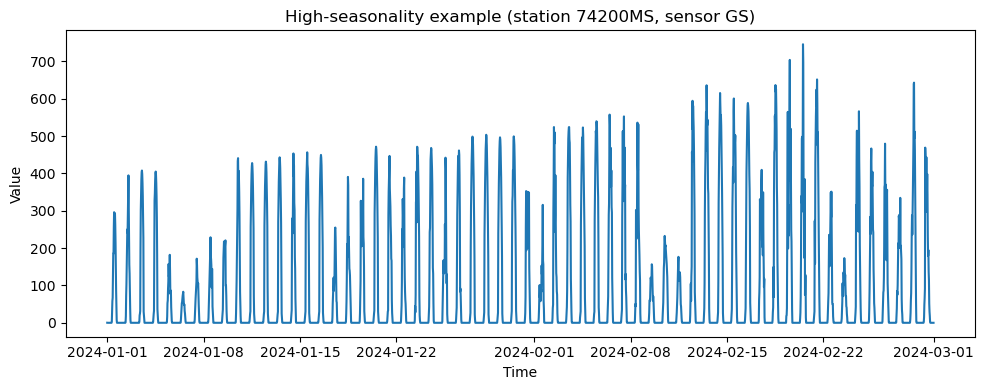

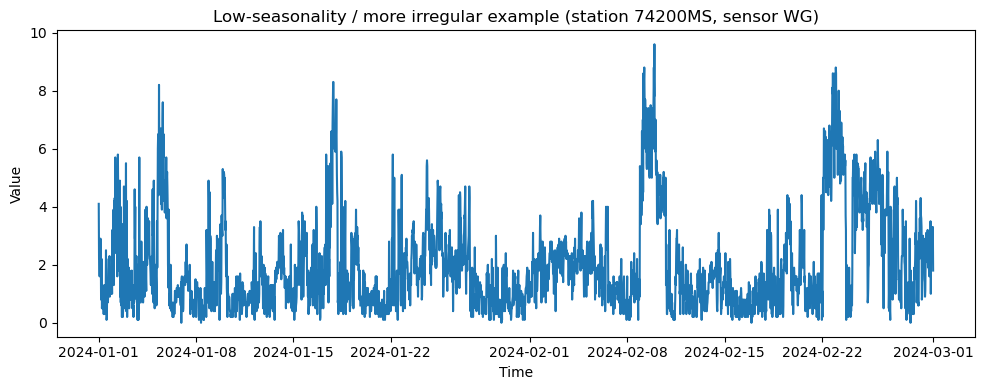

('high_seasonality.png', 'low_seasonality.png')

In [34]:
# Replot with non-NaN window and save
plt.figure(figsize=(10,4))
plt.plot(seasonal_win.index.tz_convert(None), seasonal_win.values)
plt.title(f"High-seasonality example (station {station}, sensor {seasonal_sensor})")
plt.xlabel("Time")
plt.ylabel("Value")
plt.tight_layout()
p1 =  "high_seasonality.png"
#plt.savefig(p1, dpi=200)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(normal_win.index.tz_convert(None), normal_win.values)
plt.title(f"Low-seasonality / more irregular example (station {station}, sensor {normal_sensor})")
plt.xlabel("Time")
plt.ylabel("Value")
plt.tight_layout()
p2 =  "low_seasonality.png"
#plt.savefig(p2, dpi=200)
plt.show()

str(p1), str(p2)


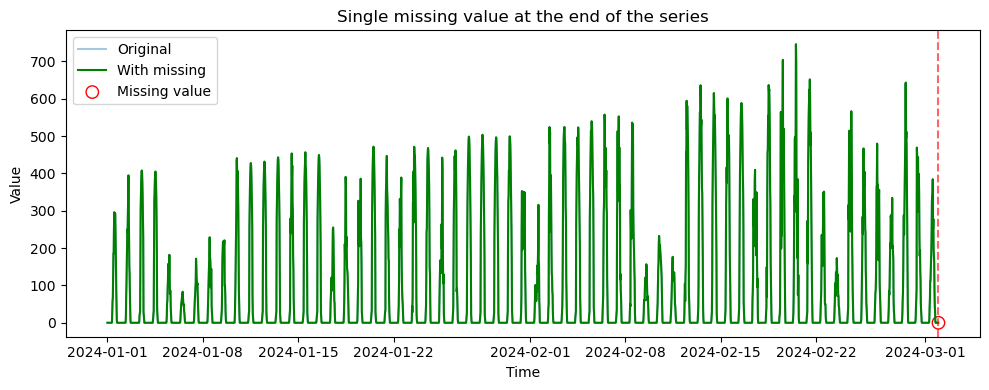

In [ ]:
# Use your already selected series
ts = seasonal.copy()

# Pick a clean continuous segment
ts = ts.loc["2024-01-01":"2024-03-01"].copy()

# Introduce missing value at the END
t_end = ts.index[-1]
ts_end_missing = ts.copy()
ts_end_missing.loc[t_end] = np.nan

# Plot
plt.figure(figsize=(10,4))
plt.plot(ts.index, ts.values, label="Original", alpha=0.4)
plt.plot(ts_end_missing.index, ts_end_missing.values, label="With missing", color="green")

plt.scatter(t_end, ts.loc[t_end], 
            facecolors="none", edgecolors="red", s=80, label="Missing value")

plt.axvline(t_end, linestyle="--", color="red", alpha=0.6)

plt.title("Single missing value at the end of the series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()


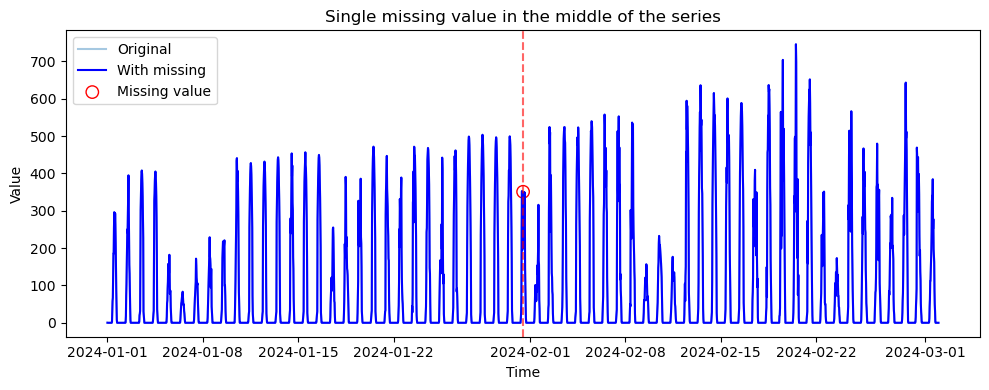

In [ ]:
# Introduce missing value in the MIDDLE
mid_idx = ts.index[len(ts)//2]
ts_mid_missing = ts.copy()
ts_mid_missing.loc[mid_idx] = np.nan

# Plot
plt.figure(figsize=(10,4))
plt.plot(ts.index, ts.values, label="Original", alpha=0.4)
plt.plot(ts_mid_missing.index, ts_mid_missing.values, label="With missing", color="blue")

plt.scatter(mid_idx, ts.loc[mid_idx], 
            facecolors="none", edgecolors="red", s=80, label="Missing value")

plt.axvline(mid_idx, linestyle="--", color="red", alpha=0.6)

plt.title("Single missing value in the middle of the series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Base clean segment (same as before)
ts = seasonal.copy()
ts = ts.loc["2024-01-01":"2024-03-01"].copy()

# Sampling frequency
freq = "30min"   # confirmed from data

In [ ]:
# 1 day = 48 points (30-min sampling)

# Block size
block_1d = 48

# Start block in the middle (fair + visible)
start_idx = len(ts)//2 - block_1d//2
end_idx = start_idx + block_1d

block_range_1d = ts.index[start_idx:end_idx]

ts_1d_missing = ts.copy()
ts_1d_missing.loc[block_range_1d] = np.nan


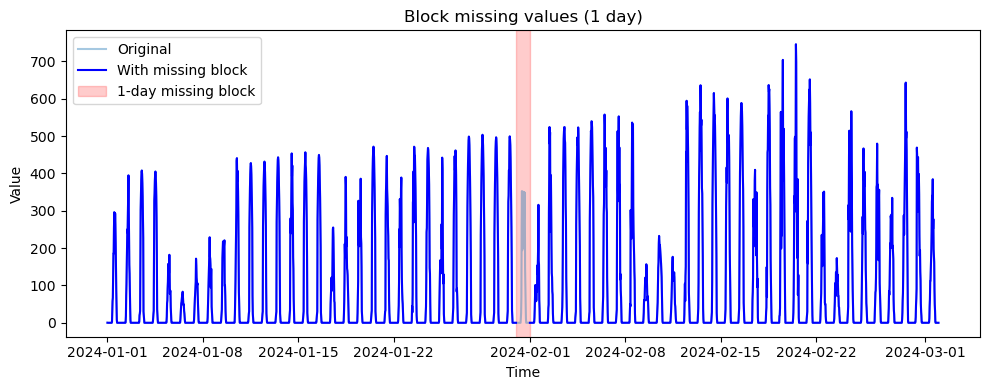

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ts.index, ts.values, alpha=0.4, label="Original")
plt.plot(ts_1d_missing.index, ts_1d_missing.values, color="blue", label="With missing block")

plt.axvspan(block_range_1d[0], block_range_1d[-1],
            color="red", alpha=0.2, label="1-day missing block")

plt.title("Block missing values (1 day)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# 1 week = 7 × 48 = 336 points

# Block size
block_1w = 336

# Same logic: centered block
start_idx = len(ts)//2 - block_1w//2
end_idx = start_idx + block_1w

block_range_1w = ts.index[start_idx:end_idx]

ts_1w_missing = ts.copy()
ts_1w_missing.loc[block_range_1w] = np.nan


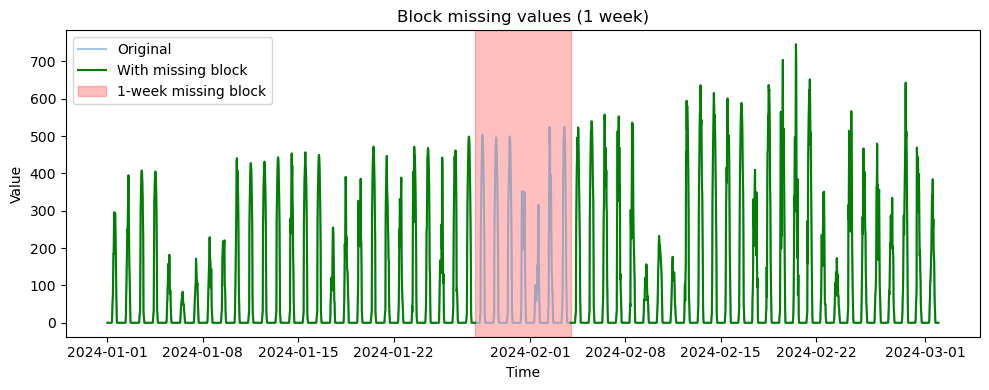

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ts.index, ts.values, alpha=0.4, label="Original")
plt.plot(ts_1w_missing.index, ts_1w_missing.values, color="green", label="With missing block")

plt.axvspan(block_range_1w[0], block_range_1w[-1],
            color="red", alpha=0.25, label="1-week missing block")

plt.title("Block missing values (1 week)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
station = "74200MS"

target_sensor = "GS"     # s
ref1_sensor = "LT"       # r1
ref2_sensor = "SD"       # r2


In [ ]:
def get_series(station, sensor):
    s = df[
        (df["station_code"] == station) &
        (df["sensor_code"] == sensor)
    ].copy()

    s = (
        s.sort_values("timestamp")
         .groupby("timestamp")["value"]
         .mean()
         .resample("30min")
         .mean()
    )
    return s

s  = get_series(station, target_sensor)
r1 = get_series(station, ref1_sensor)
r2 = get_series(station, ref2_sensor)

# Common time window
start = "2024-01-01"
end   = "2024-03-01"

s  = s.loc[start:end]
r1 = r1.loc[start:end]
r2 = r2.loc[start:end]


In [ ]:
block_len = 48 * 2   # 1 day (adjust to 1 week = 336)

missing_block = s.index[-block_len:]

s_missing = s.copy()
s_missing.loc[missing_block] = np.nan


In [ ]:
# Two historical candidate blocks
tj_start = s.index[300]
ti_start = s.index[900]

P_tj = (tj_start, tj_start + pd.Timedelta(minutes=30*block_len))
P_ti = (ti_start, ti_start + pd.Timedelta(minutes=30*block_len))


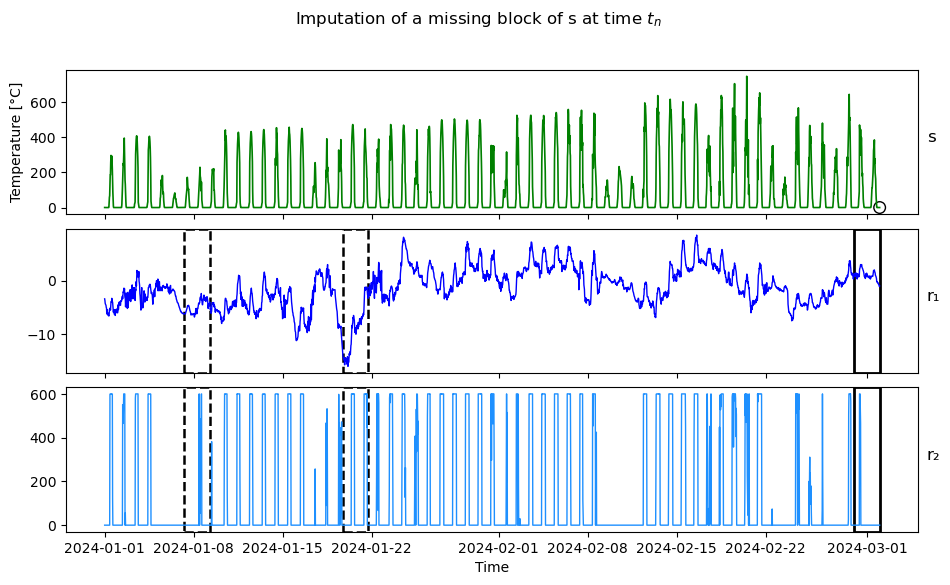

In [ ]:
fig, axes = plt.subplots(
    3, 1, figsize=(11, 6), sharex=True,
    gridspec_kw={"hspace": 0.1}
)

# ---------- s (target) ----------
axes[0].plot(s.index, s.values, color="green", lw=1.2)
axes[0].scatter(
    missing_block[-1],
    s.loc[missing_block[-1]],
    facecolors="none", edgecolors="black", s=70
)

axes[0].set_ylabel("Temperature [°C]")
axes[0].text(1.01, 0.5, "s", transform=axes[0].transAxes, fontsize=12)

# ---------- r1 ----------
axes[1].plot(r1.index, r1.values, color="blue", lw=1)

axes[1].axvspan(*P_tj, fill=False, linestyle="--", linewidth=1.8)
axes[1].axvspan(*P_ti, fill=False, linestyle="--", linewidth=1.8)
axes[1].axvspan(missing_block[0], missing_block[-1],
                fill=False, linewidth=2)

axes[1].text(1.01, 0.5, "r₁", transform=axes[1].transAxes, fontsize=12)

# ---------- r2 ----------
axes[2].plot(r2.index, r2.values, color="dodgerblue", lw=1)

axes[2].axvspan(*P_tj, fill=False, linestyle="--", linewidth=1.8)
axes[2].axvspan(*P_ti, fill=False, linestyle="--", linewidth=1.8)
axes[2].axvspan(missing_block[0], missing_block[-1],
                fill=False, linewidth=2)

axes[2].text(1.01, 0.5, "r₂", transform=axes[2].transAxes, fontsize=12)

# ---------- shared ----------
axes[2].set_xlabel("Time")

plt.suptitle(
    "Imputation of a missing block of s at time $t_n$",
    fontsize=12, y=0.98
)

plt.tight_layout()
plt.show()


In [ ]:
block_len = 48 * 2  # 1 day (use 336 for 1 week)

missing_block = s.index[-block_len:]

s_missing = s.copy()
s_missing.loc[missing_block] = np.nan


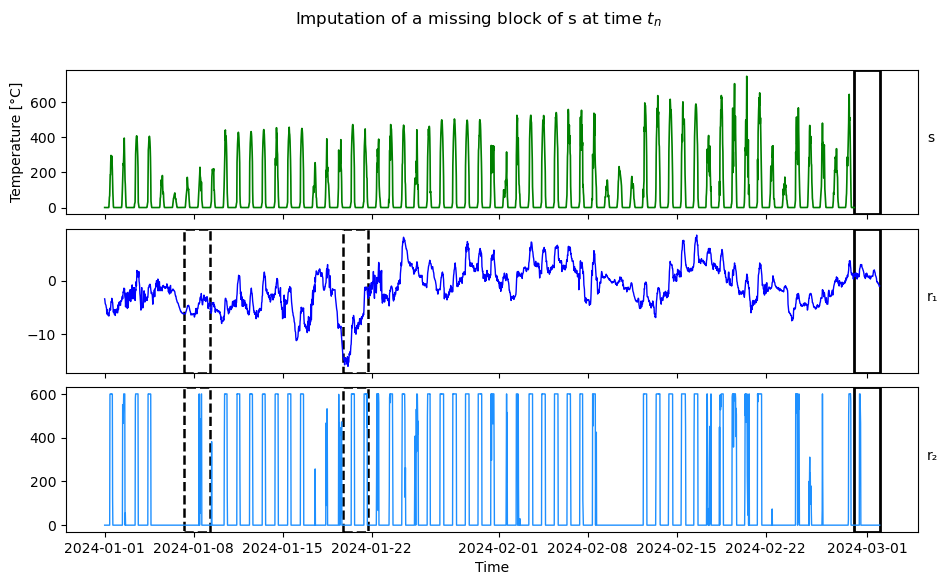

In [ ]:
fig, axes = plt.subplots(
    3, 1, figsize=(11, 6), sharex=True,
    gridspec_kw={"hspace": 0.1}
)

# ---------------- s (target) ----------------
axes[0].plot(s_missing.index, s_missing.values,
             color="green", lw=1.2)

# Highlight missing block
axes[0].axvspan(
    missing_block[0],
    missing_block[-1],
    fill=False,
    linewidth=2
)

axes[0].set_ylabel("Temperature [°C]")
axes[0].text(1.01, 0.5, "s", transform=axes[0].transAxes)

# ---------------- r1 ----------------
axes[1].plot(r1.index, r1.values, color="blue", lw=1)

axes[1].axvspan(*P_tj, fill=False, linestyle="--", linewidth=1.8)
axes[1].axvspan(*P_ti, fill=False, linestyle="--", linewidth=1.8)
axes[1].axvspan(missing_block[0], missing_block[-1],
                fill=False, linewidth=2)

axes[1].text(1.01, 0.5, "r₁", transform=axes[1].transAxes)

# ---------------- r2 ----------------
axes[2].plot(r2.index, r2.values, color="dodgerblue", lw=1)

axes[2].axvspan(*P_tj, fill=False, linestyle="--", linewidth=1.8)
axes[2].axvspan(*P_ti, fill=False, linestyle="--", linewidth=1.8)
axes[2].axvspan(missing_block[0], missing_block[-1],
                fill=False, linewidth=2)

axes[2].text(1.01, 0.5, "r₂", transform=axes[2].transAxes)

axes[2].set_xlabel("Time")

plt.suptitle(
    "Imputation of a missing block of s at time $t_n$",
    fontsize=12
)

plt.tight_layout()
plt.show()


In [ ]:
# Use the same seasonal series
ts = seasonal.copy()
ts = ts.loc["2024-01-01":"2024-03-01"].copy()

In [ ]:
ts_end_missing = ts.copy()

t_end = ts.index[-1]
ts_end_missing.loc[t_end] = np.nan


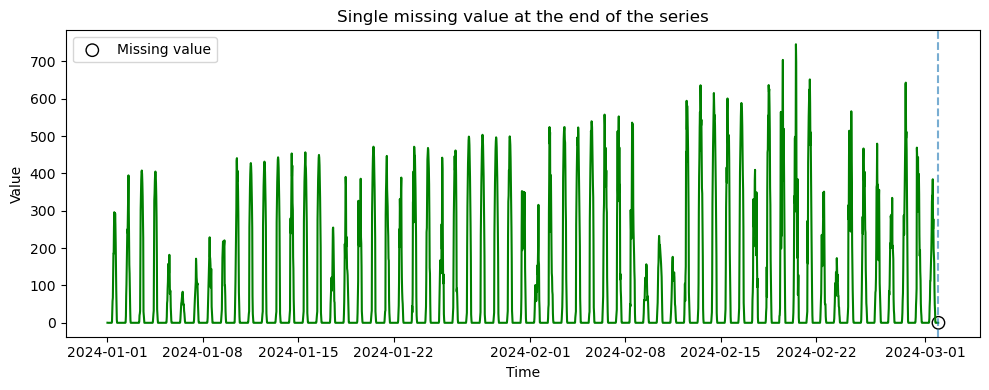

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ts_end_missing.index, ts_end_missing.values, color="green")

# Mark missing value
plt.scatter(
    t_end,
    ts.loc[t_end],
    facecolors="none",
    edgecolors="black",
    s=80,
    label="Missing value"
)

plt.axvline(t_end, linestyle="--", alpha=0.6)

plt.title("Single missing value at the end of the series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
ts_mid_missing = ts.copy()

t_mid = ts.index[len(ts)//2]
ts_mid_missing.loc[t_mid] = np.nan


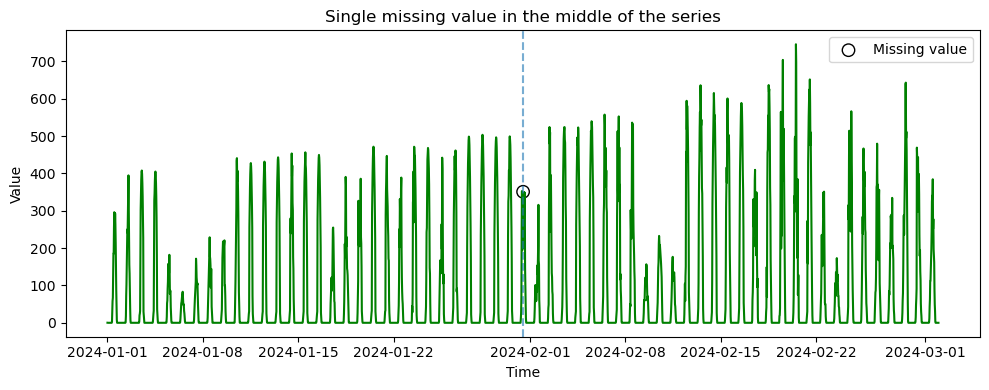

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ts_mid_missing.index, ts_mid_missing.values, color="green")

# Mark missing value
plt.scatter(
    t_mid,
    ts.loc[t_mid],
    facecolors="none",
    edgecolors="black",
    s=80,
    label="Missing value"
)

plt.axvline(t_mid, linestyle="--", alpha=0.6)

plt.title("Single missing value in the middle of the series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
ts_mid = ts.copy()
t_mid = ts.index[len(ts)//2]
ts_mid.loc[t_mid] = np.nan

In [ ]:
zoom_window = ts.loc[
    t_mid - pd.Timedelta(days=2):
    t_mid + pd.Timedelta(days=2)
]


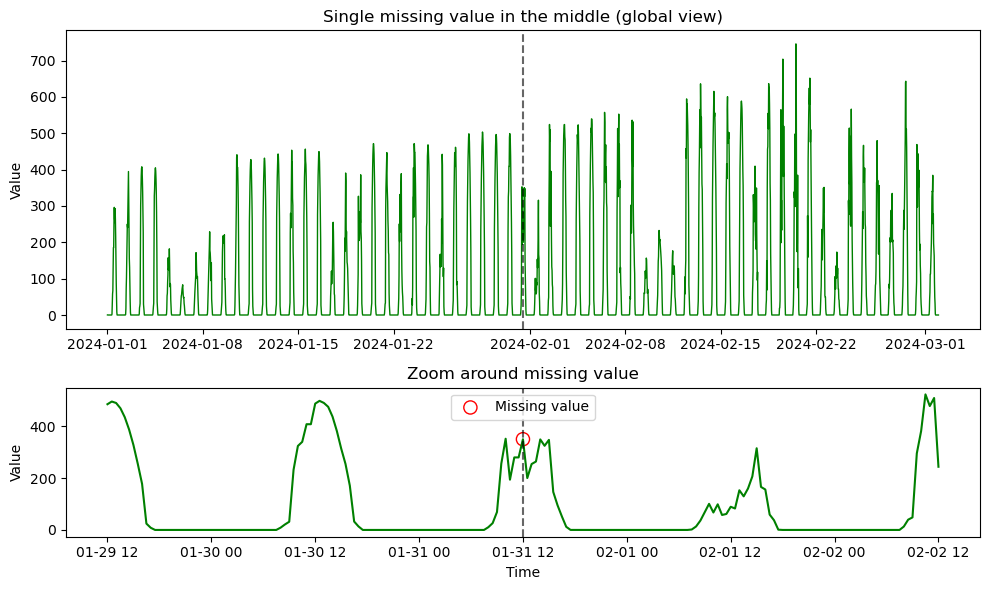

In [ ]:
fig, (ax_main, ax_zoom) = plt.subplots(
    2, 1, figsize=(10, 6),
    gridspec_kw={"height_ratios": [2, 1]},
    sharex=False
)

# -------- MAIN PLOT (context) --------
ax_main.plot(ts_mid.index, ts_mid.values, color="green", lw=1)
ax_main.axvline(t_mid, linestyle="--", color="black", alpha=0.6)
ax_main.set_title("Single missing value in the middle (global view)")
ax_main.set_ylabel("Value")

# -------- ZOOM PLOT (visibility) --------
ax_zoom.plot(zoom_window.index, zoom_window.values, color="green", lw=1.5)

ax_zoom.scatter(
    t_mid,
    ts.loc[t_mid],
    facecolors="none",
    edgecolors="red",
    s=90,
    label="Missing value"
)

ax_zoom.axvline(t_mid, linestyle="--", color="black", alpha=0.6)

ax_zoom.set_title("Zoom around missing value")
ax_zoom.set_xlabel("Time")
ax_zoom.set_ylabel("Value")
ax_zoom.legend()

plt.tight_layout()
plt.show()


In [ ]:
ts_end = ts.copy()
t_end = ts.index[-1]
ts_end.loc[t_end] = np.nan


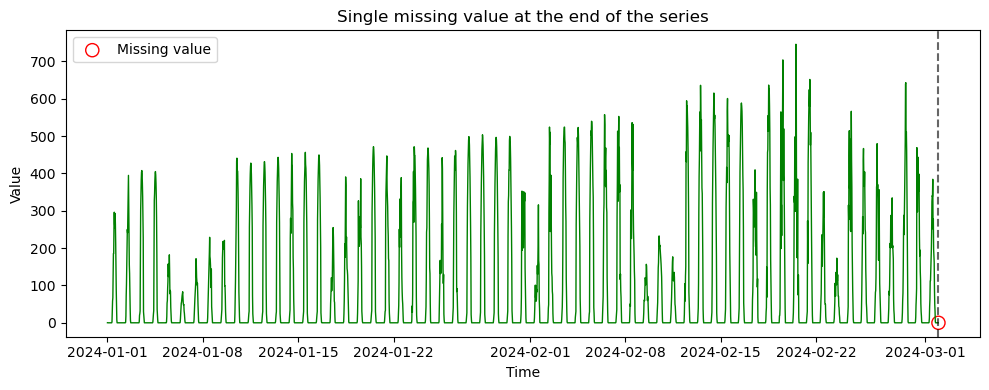

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ts_end.index, ts_end.values, color="green", lw=1)

plt.scatter(
    t_end,
    ts.loc[t_end],
    facecolors="none",
    edgecolors="red",
    s=90,
    label="Missing value"
)

plt.axvline(t_end, linestyle="--", color="black", alpha=0.6)

plt.title("Single missing value at the end of the series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()


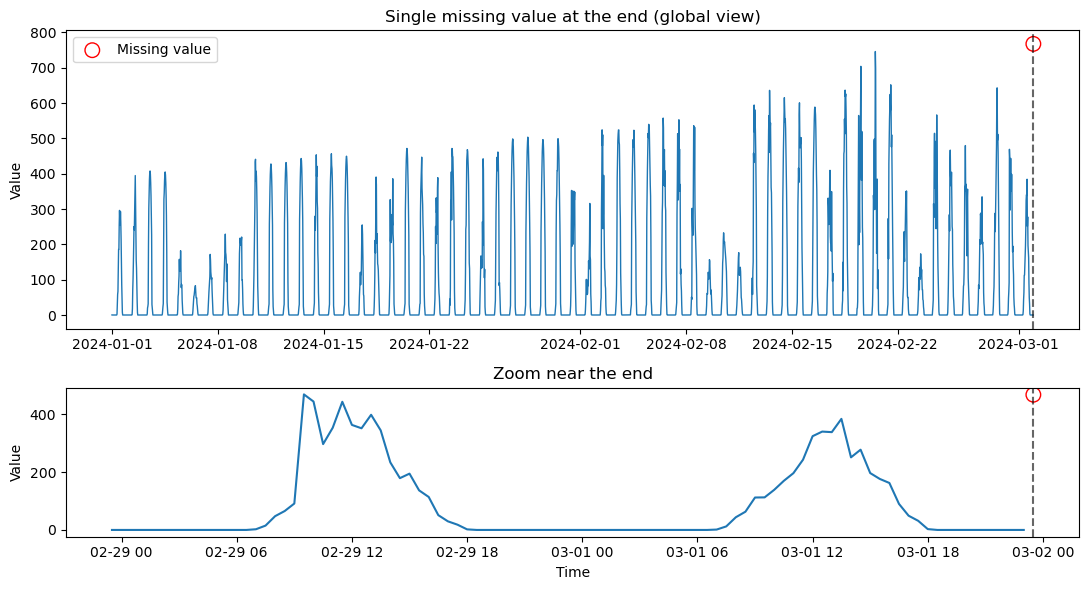

In [ ]:

# --- base series ---
ts = seasonal.copy().loc["2024-01-01":"2024-03-01"].copy()

# --- make single missing at END ---
ts_end = ts.copy()
t_end = ts_end.index[-1]
ts_end.loc[t_end] = np.nan

# --- zoom window (last 2 days) ---
zoom = ts_end.loc[t_end - pd.Timedelta(days=2): t_end]

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(11, 6),
    gridspec_kw={"height_ratios": [2, 1]},
    sharex=False
)

# ========== MAIN (full context) ==========
ax1.plot(ts_end.index, ts_end.values, lw=1)
ax1.axvline(t_end, linestyle="--", color="black", alpha=0.6)
ax1.set_title("Single missing value at the end (global view)")
ax1.set_ylabel("Value")

# Put a visible marker at the TOP of the axis at missing timestamp (independent of y)
y_top = ax1.get_ylim()[1]
ax1.scatter([t_end], [y_top * 0.98], facecolors="none", edgecolors="red", s=110, label="Missing value")
ax1.legend(loc="upper left")

# ========== ZOOM (last part) ==========
ax2.plot(zoom.index, zoom.values, lw=1.5)
ax2.axvline(t_end, linestyle="--", color="black", alpha=0.6)
ax2.set_title("Zoom near the end")
ax2.set_xlabel("Time")
ax2.set_ylabel("Value")

# Again: marker at top of zoom axis
y_top2 = ax2.get_ylim()[1]
ax2.scatter([t_end], [y_top2 * 0.95], facecolors="none", edgecolors="red", s=110)

plt.tight_layout()
plt.show()


In [ ]:
BLOCK_SIZES = {
    "1 day": 48,
    "1 week": 336,
    "1 month": 1440
}

In [ ]:
def plot_block_missing_with_zoom(
    ts,
    block_len,
    position="end",      # "end" or "middle"
    title=""
):
    ts_missing = ts.copy()

    # --- define block position ---
    if position == "end":
        start_idx = len(ts) - block_len
        end_idx = len(ts)
    elif position == "middle":
        mid = len(ts) // 2
        start_idx = mid - block_len // 2
        end_idx = start_idx + block_len
    else:
        raise ValueError("position must be 'end' or 'middle'")

    block_index = ts.index[start_idx:end_idx]
    ts_missing.loc[block_index] = np.nan

    # --- zoom window ---
    zoom_start = block_index[0] - pd.Timedelta(days=2)
    zoom_end   = block_index[-1] + pd.Timedelta(days=2)
    zoom_ts = ts_missing.loc[zoom_start:zoom_end]

    # --- plotting ---
    fig, (ax_main, ax_zoom) = plt.subplots(
        2, 1, figsize=(11, 6),
        gridspec_kw={"height_ratios": [2, 1]},
        sharex=False
    )

    # ===== MAIN =====
    ax_main.plot(ts_missing.index, ts_missing.values, lw=1)
    ax_main.axvspan(block_index[0], block_index[-1],
                    fill=False, linewidth=2, edgecolor="red")
    ax_main.set_title(title + " (global view)")
    ax_main.set_ylabel("Value")

    # ===== ZOOM =====
    ax_zoom.plot(zoom_ts.index, zoom_ts.values, lw=1.5)
    ax_zoom.axvspan(block_index[0], block_index[-1],
                    fill=False, linewidth=2, edgecolor="red")
    ax_zoom.set_title("Zoom around missing block")
    ax_zoom.set_xlabel("Time")
    ax_zoom.set_ylabel("Value")

    plt.tight_layout()
    plt.show()


In [ ]:
ts = seasonal.copy().loc["2024-01-01":"2024-03-01"]

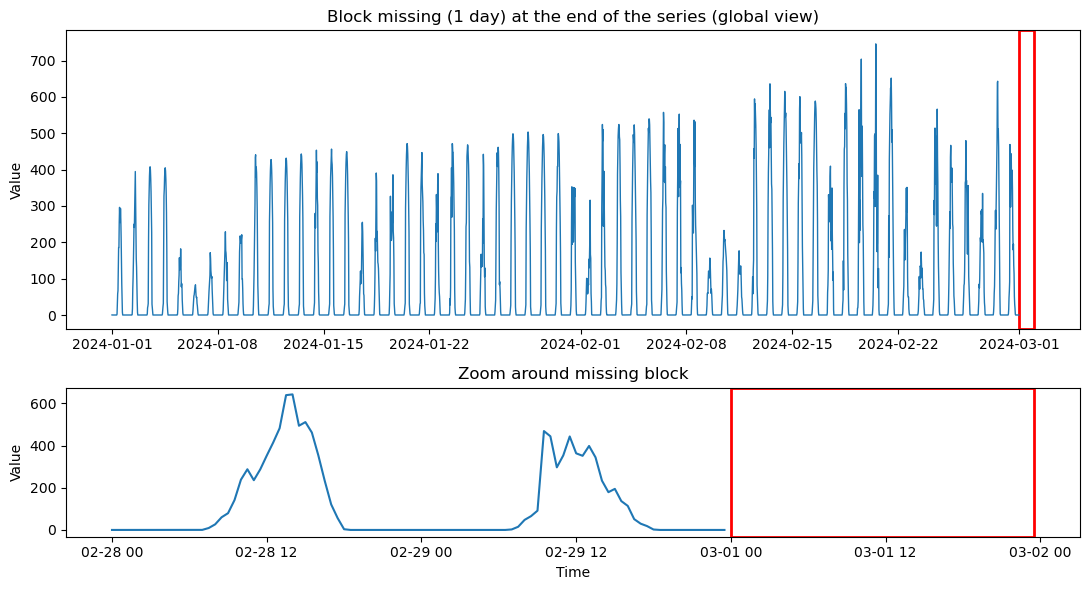

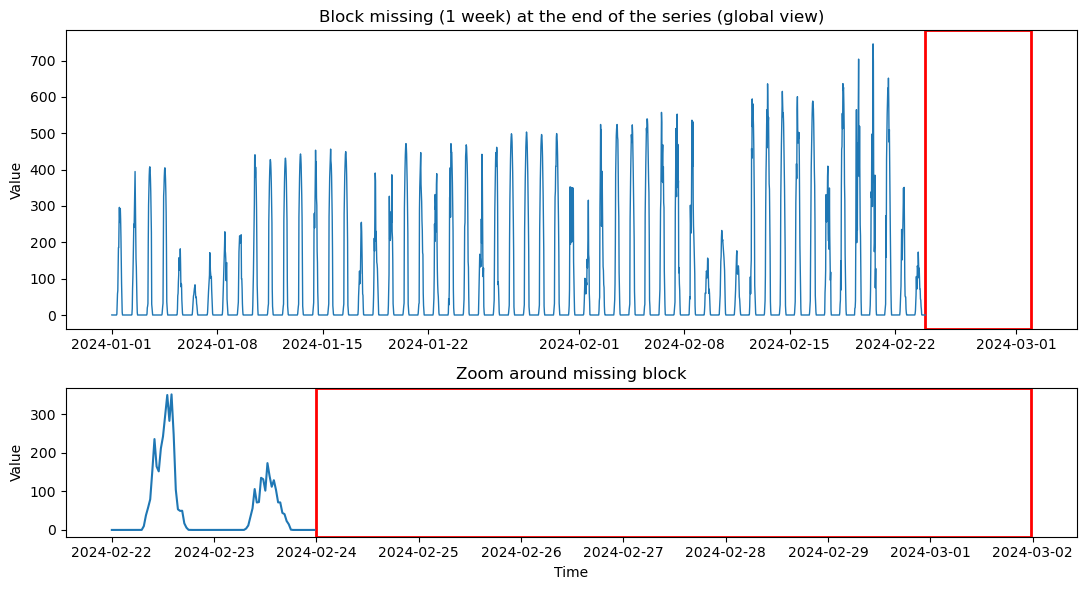

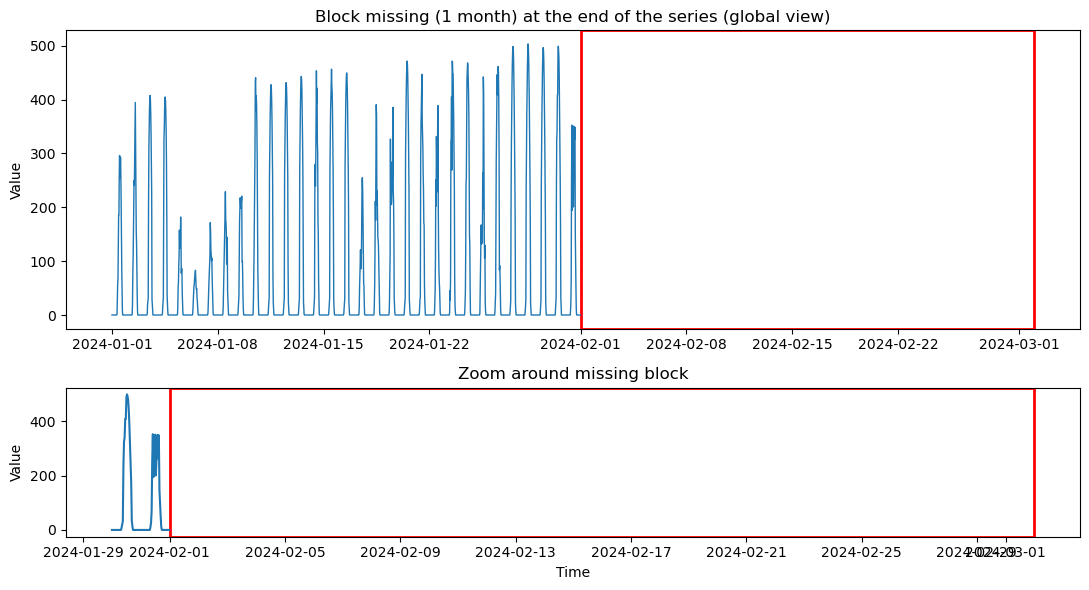

In [ ]:
for label, size in BLOCK_SIZES.items():
    plot_block_missing_with_zoom(
        ts,
        block_len=size,
        position="end",
        title=f"Block missing ({label}) at the end of the series"
    )


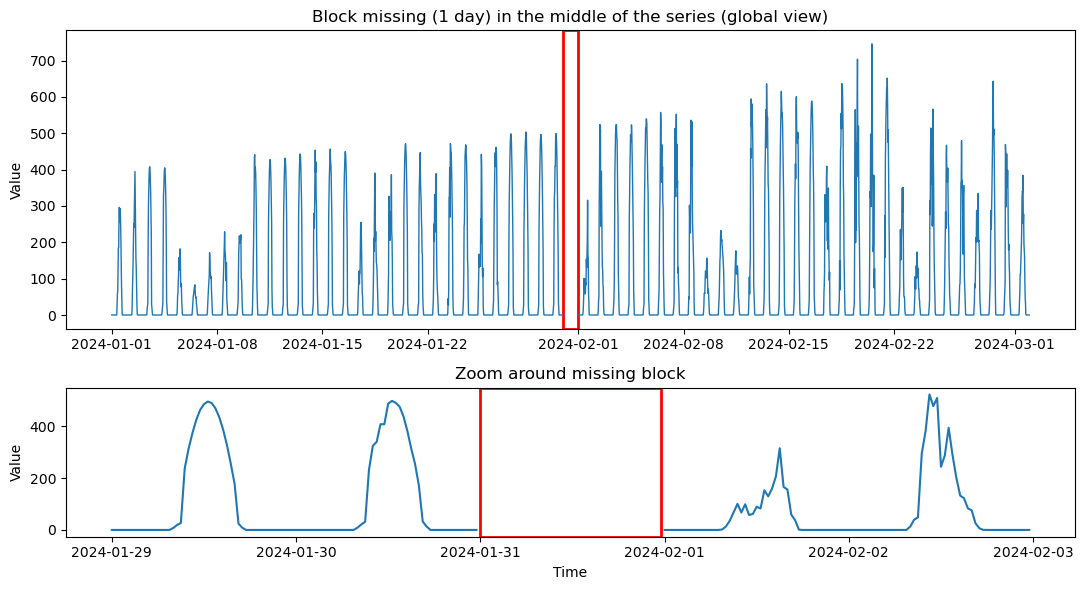

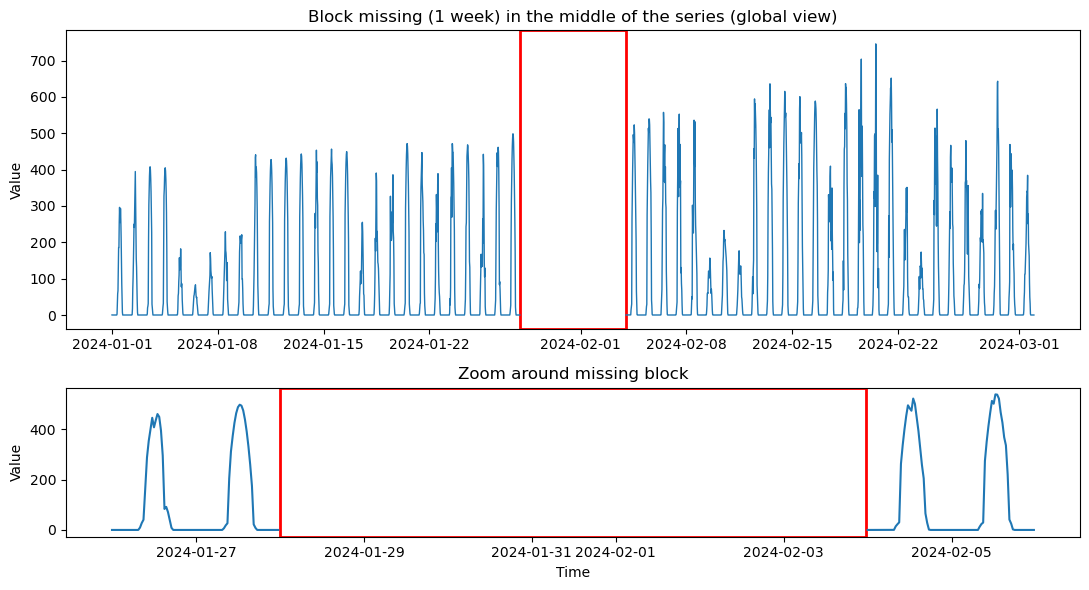

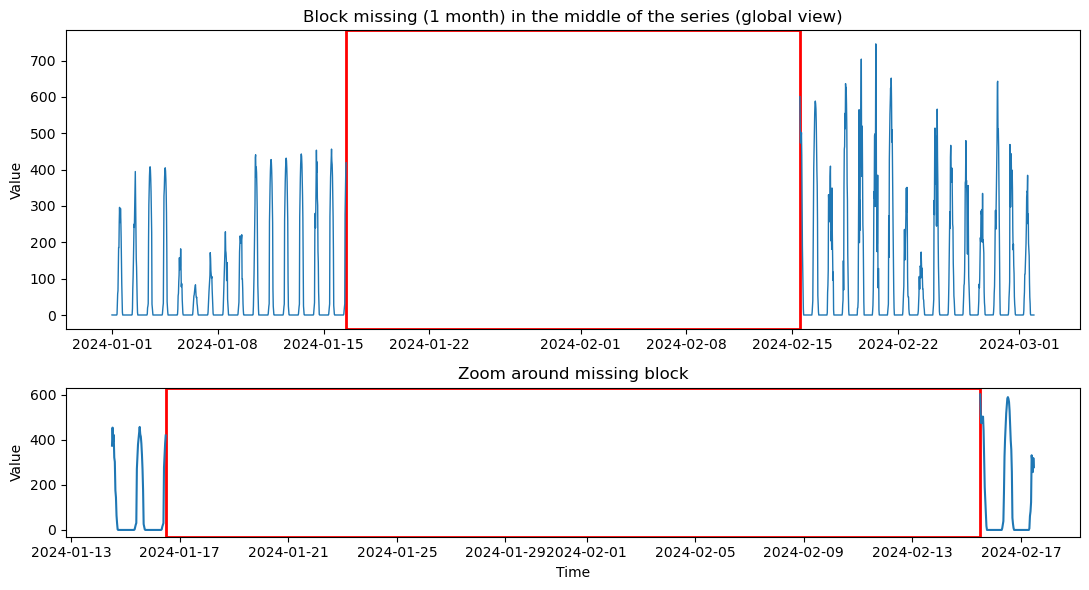

In [ ]:
for label, size in BLOCK_SIZES.items():
    plot_block_missing_with_zoom(
        ts,
        block_len=size,
        position="middle",
        title=f"Block missing ({label}) in the middle of the series"
    )


In [ ]:
def plot_block_missing_clean(
    ts,
    block_len,
    position="middle",
    title=""
):
    ts_miss = ts.copy()

    # --- define block ---
    if position == "end":
        start = len(ts) - block_len
        end = len(ts)
    else:  # middle
        mid = len(ts) // 2
        start = mid - block_len // 2
        end = start + block_len

    block_idx = ts.index[start:end]
    ts_miss.loc[block_idx] = np.nan

    # --- zoom window: tight ---
    zoom_pad = block_len // 2
    zoom_start = max(0, start - zoom_pad)
    zoom_end = min(len(ts), end + zoom_pad)
    zoom_ts = ts_miss.iloc[zoom_start:zoom_end]

    # --- plot ---
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(11, 6),
        gridspec_kw={"height_ratios": [2, 1]}
    )

    # ===== GLOBAL =====
    ax1.plot(ts_miss.index, ts_miss.values, lw=0.9)
    ax1.axvspan(block_idx[0], block_idx[-1],
                color="red", alpha=0.15)
    ax1.set_title(title + " (global view)")
    ax1.set_ylabel("Value")

    # ===== ZOOM =====
    ax2.plot(zoom_ts.index, zoom_ts.values, lw=1.2)
    ax2.axvspan(block_idx[0], block_idx[-1],
                color="red", alpha=0.25)
    ax2.set_title("Zoom: missing block")
    ax2.set_xlabel("Time")
    ax2.set_ylabel("Value")

    # Explicit annotation (VERY IMPORTANT)
    ax2.annotate(
        "Missing block",
        xy=(block_idx[len(block_idx)//2], ax2.get_ylim()[1]*0.9),
        xytext=(0, 0),
        textcoords="offset points",
        ha="center",
        fontsize=10,
        color="red"
    )

    plt.tight_layout()
    plt.show()


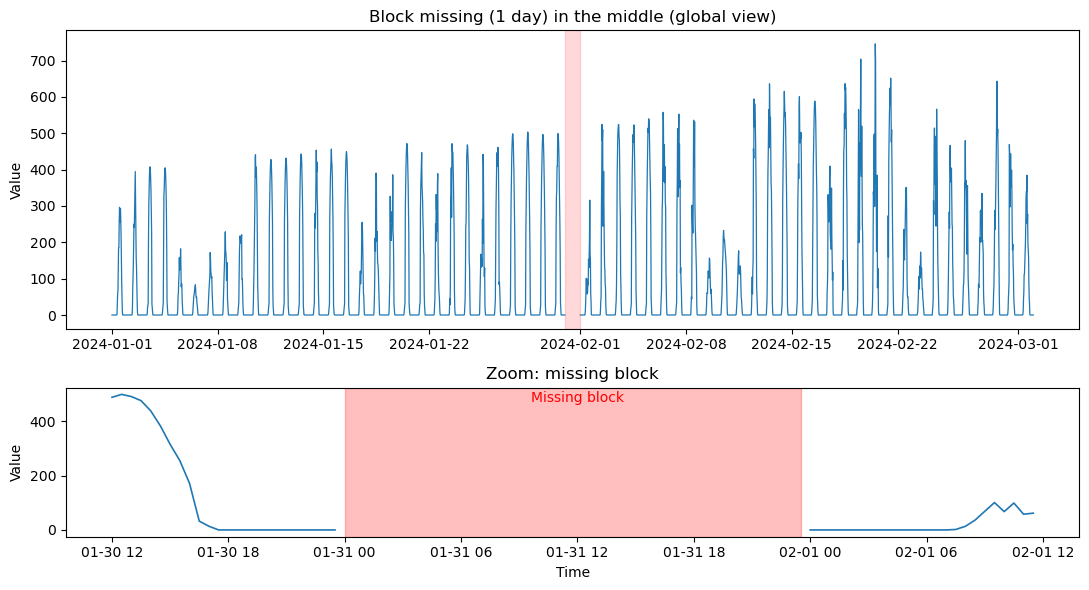

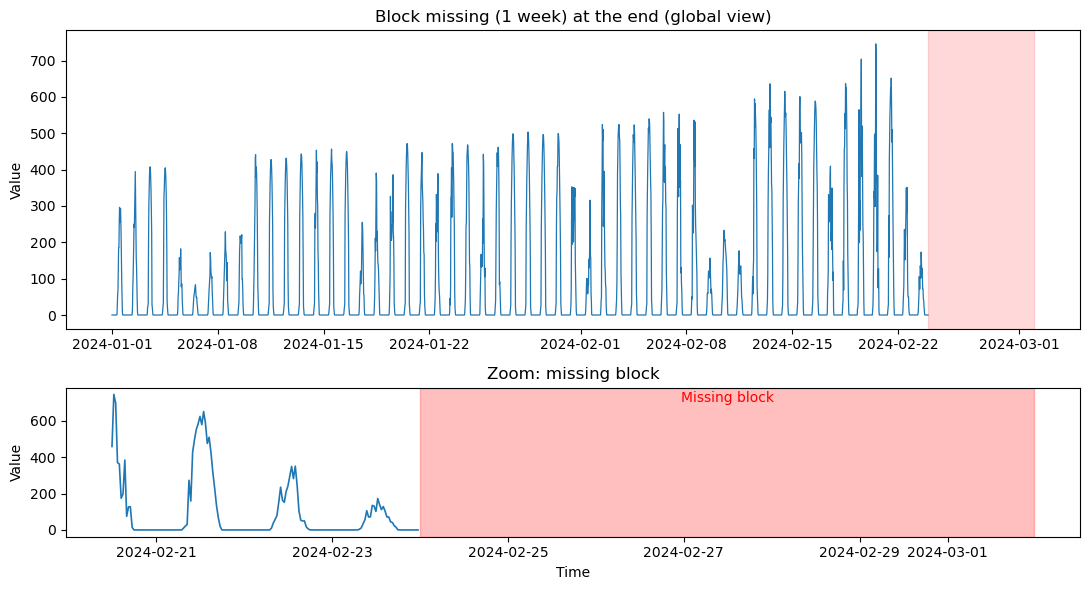

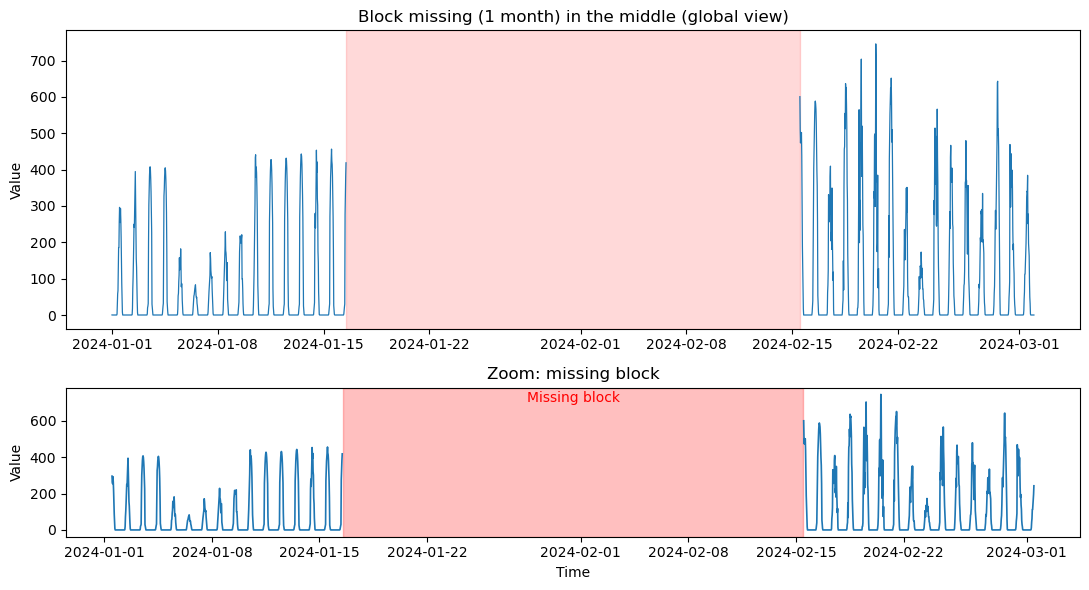

In [ ]:
# 1 day
plot_block_missing_clean(
    ts,
    block_len=48,
    position="middle",
    title="Block missing (1 day) in the middle"
)

# 1 week
plot_block_missing_clean(
    ts,
    block_len=336,
    position="end",
    title="Block missing (1 week) at the end"
)

# 1 month
plot_block_missing_clean(
    ts,
    block_len=1440,
    position="middle",
    title="Block missing (1 month) in the middle"
)


In [ ]:
valley_df.head()

,station_code,sensor_code,description_it,unit,timestamp,value
0,37100MS,LT,Temperatura dell´aria,°C,2025-01-01 00:00:00,-10.4
1,37100MS,LT,Temperatura dell´aria,°C,2024-12-31 23:30:00,-8.9
2,37100MS,LT,Temperatura dell´aria,°C,2024-12-31 23:00:00,-9.5
3,37100MS,LT,Temperatura dell´aria,°C,2024-12-31 22:30:00,-8.1
4,37100MS,LT,Temperatura dell´aria,°C,2024-12-31 22:00:00,-8.8


In [ ]:
valley_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7079427 entries, 0 to 7079426
Data columns (total 6 columns):
 #   Column          Dtype  
---  ------          -----  
 0   station_code    object 
 1   sensor_code     object 
 2   description_it  object 
 3   unit            object 
 4   timestamp       object 
 5   value           float64
dtypes: float64(1), object(5)
memory usage: 324.1+ MB


In [ ]:
valley_df.describe()

,value
count,7.079427e+06
mean,1.722966e+02
std,3.336668e+02
min,-9.760000e+01
25%,0.000000e+00
50%,3.600000e+00
75%,1.000000e+02
max,1.474800e+03


In [ ]:
# Preview data
print("🔍 Shape:", valley_df.shape)

🔍 Shape: (7079427, 6)


In [ ]:
# Check which columns are non-numeric
print("🧠 Columns in the file:\n", valley_df.dtypes)

🧠 Columns in the file:
 station_code       object
sensor_code        object
description_it     object
unit               object
timestamp          object
value             float64
dtype: object


In [ ]:
unique_values = valley_df['sensor_code'].unique()
unique_values

array(['LT', 'N', 'WR', 'WG', 'WG.BOE', 'LF', 'LD.RED', 'GS', 'SD', 'HS',
       'W', 'WT'], dtype=object)

In [ ]:
unique_values1 = valley_df['station_code'].unique()
unique_values1

array(['37100MS', '20500MS', '19300MS', '80300MS', '50500MS', '34500MS',
       '56900MS', '54500MS', '69900MS', '09700MS', '82200MS', '88820MS',
       '59700MS', '85120MS', '83200MS', '86900MS', '39100MS', '08200MS',
       '23200MS', '47400MS', '86600MS', '37700MS', '74900MS', '89190MS',
       '22210MS', '25900MS', '73500MS', '68600MS', '02200MS', '03100MS',
       '41000MS', '75600MS', '62600MS', '74200MS', '11400MS', '02500MS',
       '33500MS', '44500MS', '06400MS', '65600MS', '24400MS', '43200MS',
       '78305MS', '56500MS', '42700MS', '15800MS', '65350MS', '89950SE',
       '02250SE', '78150SE', '82910MS', '47150SE', '27100MS', '89155SE',
       '89355SE', '85700MS', '89055SE', '42150SE', '39050SE', '79450SE',
       '87300MS', '66500MS', '20910MS', '31410MS', '78110MS', '61300MS',
       '01110MS', '71510MS', '79300MS', '75510SE', '90150SE', '91510MS'],
      dtype=object)

In [ ]:
unique_values2 = valley_df['description_it'].unique()
unique_values2

array(['Temperatura dell´aria', 'Precipitazioni', 'Direzione del vento',
       'Velocità del vento', 'Velocitá raffica', 'Umidità relativa',
       'Pressione atmosferica', 'Radiazione globale ',
       'Durata soleggiamento', 'Altezza neve al suolo',
       'Livello idrometrico', 'Temperatura acqua'], dtype=object)

In [ ]:
unique_values3 = valley_df['unit'].unique()
unique_values3

array(['°C', 'mm', '° ', 'm/s', '%', 'hPa', 'W/m²', 's', 'cm'],
      dtype=object)

In [ ]:
unique_values4 = valley_df['value'].unique()
unique_values4

array([-10.4,  -8.9,  -9.5, ..., 981.9, 855.3, 802.7], shape=(11245,))

In [ ]:
column_names = list(valley_df.columns)
column_names

['station_code', 'sensor_code', 'description_it', 'unit', 'timestamp', 'value']

In [ ]:
zero_counts = (valley_df == 0).sum()
print(zero_counts)

station_code            0
sensor_code             0
description_it          0
unit                    0
timestamp               0
value             1667902
dtype: int64


In [ ]:
valley_df[valley_df["value"] == 0].head()

,station_code,sensor_code,description_it,unit,timestamp,value
116,37100MS,LT,Temperatura dell´aria,°C,2024-12-29 14:00:00,0.0
338,37100MS,LT,Temperatura dell´aria,°C,2024-12-24 23:00:00,0.0
426,37100MS,LT,Temperatura dell´aria,°C,2024-12-23 03:00:00,0.0
598,37100MS,LT,Temperatura dell´aria,°C,2024-12-19 13:00:00,0.0
637,37100MS,LT,Temperatura dell´aria,°C,2024-12-18 17:30:00,0.0


In [ ]:
# Make sure 'value' is numeric
valley_df['value'] = pd.to_numeric(valley_df['value'], errors='coerce')

# Group by sensor_code
zero_stats = (
    valley_df.groupby('sensor_code')
    .agg(
        total_entries=('value', 'count'),
        zero_count=('value', lambda x: (x == 0).sum())
    )
)

# Add percentage of zeros
zero_stats['zero_percentage'] = (zero_stats['zero_count'] / zero_stats['total_entries']) * 100

# Sort by percentage of zero values
zero_stats = zero_stats.sort_values(by='zero_percentage', ascending=False)

print(zero_stats.reset_index())


   sensor_code  total_entries  zero_count  zero_percentage
0            N         585918      565938        96.589967
1           SD         773271      643102        83.166445
2           GS         758400      438331        57.796809
3            W          83263        5222         6.271693
4           LT         889920        7619         0.856144
5           WG         713371        4772         0.668937
6           HS          29182         170         0.582551
7       WG.BOE         713371        2423         0.339655
8           WT          83262          60         0.072062
9           WR         713371         265         0.037148
10          LF         875328           0         0.000000
11      LD.RED         860770           0         0.000000


In [ ]:
# Step 1: Select sensor `LF`
lf_df = valley_df[valley_df['sensor_code'] == 'LF'].copy()

In [ ]:
# Step 2: Replace `0.0` values with NaN
lf_df.loc[lf_df['value'] == 0.0, 'value'] = np.nan

In [ ]:
# Step 3: Pivot to wide format (timestamp × station_code)
lf_df['timestamp'] = pd.to_datetime(lf_df['timestamp'])
pivot_df = lf_df.pivot(index='timestamp', columns='station_code', values='value')

In [ ]:
# Step 4: Drop sparse stations (>10% missing)
threshold = 0.9 * len(pivot_df)
pivot_df = pivot_df.dropna(thresh=threshold, axis=1)

In [ ]:
# Step 5: Drop rows with any missing values
clean_df = pivot_df.dropna(axis=0)

In [ ]:
clean_df

station_code,01110MS,02200MS,02500MS,03100MS,06400MS,08200MS,09700MS,11400MS,15800MS,19300MS,...,82910MS,83200MS,85120MS,85700MS,86600MS,86900MS,87300MS,88820MS,89190MS,91510MS
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,99.1,90.4,82.5,86.2,94.8,99.8,92.7,91.6,91.9,90.6,...,93.8,87.7,99.9,96.8,95.8,98.1,97.6,83.5,84.3,99.9
2023-01-01 00:30:00,98.1,90.8,80.8,84.9,97.1,99.8,91.1,92.1,92.7,91.7,...,91.8,87.0,99.9,97.7,94.5,97.0,97.5,82.7,84.3,99.9
2023-01-01 01:00:00,98.0,91.5,81.9,83.5,96.7,99.8,90.0,89.1,92.4,90.1,...,92.1,85.3,99.9,97.1,93.5,98.5,99.7,89.8,81.3,99.9
2023-01-01 01:30:00,99.7,92.6,81.1,85.3,97.7,99.8,89.4,88.5,93.3,89.2,...,95.1,84.2,99.9,98.8,92.5,99.2,96.4,90.6,83.9,99.9
2023-01-01 02:00:00,99.8,94.2,81.9,84.5,95.4,99.8,88.2,86.2,94.2,89.1,...,98.6,88.4,99.9,99.6,94.5,99.0,99.9,90.0,80.9,99.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 22:00:00,54.5,74.4,38.3,53.7,48.4,91.3,64.9,51.1,49.7,89.4,...,84.0,90.2,47.1,100.2,99.6,98.7,53.8,95.8,64.1,96.9
2024-12-31 22:30:00,54.7,75.9,41.8,56.0,46.0,91.3,67.3,51.9,50.2,90.5,...,84.5,88.9,48.7,100.2,99.1,100.0,54.0,99.0,61.4,96.0
2024-12-31 23:00:00,54.7,77.3,39.0,55.8,46.4,92.2,64.2,51.1,51.0,90.4,...,85.7,89.0,48.4,99.7,99.7,100.0,57.7,96.6,63.5,96.1


In [ ]:
# Step 6: Pick a target station (first available column)
target_station = clean_df.columns[2]

In [ ]:
target_station

'02500MS'

In [ ]:
# Step 7: Compute Pearson correlations with all other stations
correlations = clean_df.corr()[target_station].drop(index=target_station).sort_values(ascending=False)

In [ ]:
correlations

station_code
15800MS    0.860133
03100MS    0.856343
06400MS    0.820458
20910MS    0.815276
24400MS    0.812125
71510MS    0.806599
68600MS    0.800845
01110MS    0.791615
20500MS    0.790726
11400MS    0.787193
65600MS    0.757288
02200MS    0.756943
87300MS    0.755742
85120MS    0.755661
78110MS    0.751061
79300MS    0.736962
34500MS    0.730753
75600MS    0.725095
74200MS    0.723658
73500MS    0.720382
66500MS    0.720341
25900MS    0.701794
89190MS    0.688170
82200MS    0.681692
44500MS    0.661228
47400MS    0.660803
78305MS    0.656539
82910MS    0.645984
69900MS    0.640392
50500MS    0.635309
09700MS    0.633138
54500MS    0.627258
61300MS    0.615036
80300MS    0.614604
37700MS    0.610875
08200MS    0.609098
22210MS    0.560592
31410MS    0.544317
42700MS    0.535828
37100MS    0.530221
83200MS    0.519141
62600MS    0.510519
74900MS    0.487708
19300MS    0.482003
23200MS    0.477953
39100MS    0.473874
88820MS    0.465987
86900MS    0.454714
41000MS    0.453751
56500MS

In [ ]:
# Step 8: Select top 2 correlated reference stations
top_refs = correlations.head(2).index.tolist()
final_df = clean_df[[target_station] + top_refs].copy()

In [ ]:
top_refs

['15800MS', '03100MS']

In [ ]:
final_df

station_code,02500MS,15800MS,03100MS
timestamp,,,
2023-01-01 00:00:00,82.5,91.9,86.2
2023-01-01 00:30:00,80.8,92.7,84.9
2023-01-01 01:00:00,81.9,92.4,83.5
2023-01-01 01:30:00,81.1,93.3,85.3
2023-01-01 02:00:00,81.9,94.2,84.5
...,...,...,...
2024-12-31 22:00:00,38.3,49.7,53.7
2024-12-31 22:30:00,41.8,50.2,56.0
2024-12-31 23:00:00,39.0,51.0,55.8


In [ ]:
# Step 8: Build new DataFrame with target and top 3 references
top_3_refs = correlations.dropna().sort_values(ascending=False).head(3).index.tolist()
selected_stations = [target_station] + top_3_refs
pattern_df = pivot_df[selected_stations].copy()

In [ ]:
pattern_df

station_code,02500MS,15800MS,03100MS,06400MS
timestamp,,,,
2023-01-01 00:00:00,82.5,91.9,86.2,94.8
2023-01-01 00:30:00,80.8,92.7,84.9,97.1
2023-01-01 01:00:00,81.9,92.4,83.5,96.7
2023-01-01 01:30:00,81.1,93.3,85.3,97.7
2023-01-01 02:00:00,81.9,94.2,84.5,95.4
...,...,...,...,...
2024-12-31 22:00:00,38.3,49.7,53.7,48.4
2024-12-31 22:30:00,41.8,50.2,56.0,46.0
2024-12-31 23:00:00,39.0,51.0,55.8,46.4


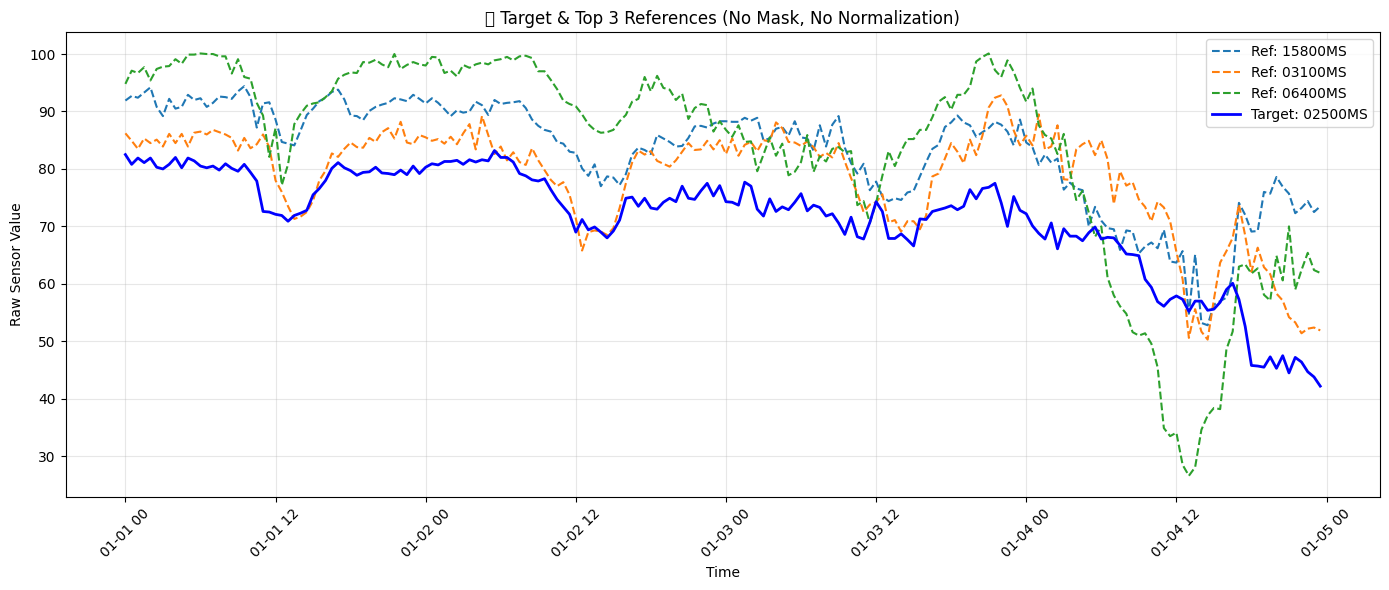

In [ ]:
# Define the stations exactly as in your DataFrame
target = "02500MS"
references = ["15800MS","03100MS","06400MS"]

# Define time range for plot (e.g., Jan 1 to Jan 4, 2023)
start_time = "2023-01-01"
end_time = "2023-01-04"

# Slice the DataFrame
plot_df = pattern_df[[target] + references].loc[start_time:end_time].copy()

# Plotting
plt.figure(figsize=(14, 6))

# Plot reference series
for ref in references:
    plt.plot(plot_df.index, plot_df[ref], linestyle='--', label=f"Ref: {ref}")

# Plot target series
plt.plot(plot_df.index, plot_df[target], color='blue', linewidth=2, label=f"Target: {target}")

plt.xlabel("Time")
plt.ylabel("Raw Sensor Value")
plt.title("📍 Target & Top 3 References (No Mask, No Normalization)")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# -------------------------------------------
# 🔹 STEP 1: Normalize the Time Series Data
# -------------------------------------------

from sklearn.preprocessing import StandardScaler

# 1️⃣ Initialize the Scaler
scaler = StandardScaler()

# 2️⃣ Fit the scaler on the full pattern_df and transform it
normalized_array = scaler.fit_transform(pattern_df)

# 3️⃣ Reconstruct a DataFrame with the same shape, columns, and index
normalized_df = pd.DataFrame(
    normalized_array,
    columns=pattern_df.columns,
    index=pattern_df.index
)

# 4️⃣ Print shape and preview
print("✅ Normalized shape:", normalized_df.shape)
display(normalized_df.head())


✅ Normalized shape: (14593, 4)


station_code,02500MS,15800MS,03100MS,06400MS
timestamp,,,,
2023-01-01 00:00:00,1.119923,1.189939,0.666856,1.250501
2023-01-01 00:30:00,1.038581,1.225965,0.609234,1.356561
2023-01-01 01:00:00,1.091214,1.212455,0.547179,1.338115
2023-01-01 01:30:00,1.052935,1.252984,0.626964,1.384229
2023-01-01 02:00:00,1.091214,1.293513,0.591504,1.278168


In [ ]:
# ---------------------------------------------------------
# 🔹 STEP 2: Define function to inject single-missing in the END
# ---------------------------------------------------------

def introduce_single_missing_end(series: pd.Series) -> Tuple[pd.Series, int, float]:
    """
    Introduce a single NaN value at the end of a time series.

    Parameters:
        series (pd.Series): The original time series

    Returns:
        masked_series (pd.Series): The modified series with one NaN at the end
        missing_index (int): Index where the value was masked
        true_value (float): The original value that was replaced with NaN
    """
    ts = series.copy()
    end_index = len(ts) - 1
    true_value = ts.iloc[end_index]
    ts.iloc[end_index] = np.nan
    return ts, end_index, true_value



In [ ]:
# ---------------------------------------------------------
# 🔹 STEP 2b: Apply block-missing to the normalized target series
# ---------------------------------------------------------

# Define target station (from your pattern_df)
target_station = "02500MS"

# Apply the masking function for a single missing value in the middle
masked_target, end_idx, true_val = introduce_single_missing_end(
    normalized_df[target_station]
)

# ✅ Optional: Print info about the missing point
print(f"🎯 Single missing value injected at index {end_idx}")
print(f"📉 True value at that point: {true_val:.4f}")
print("🕓 Timestamp of missing value:", normalized_df.index[end_idx])


🎯 Single missing value injected at index 14592
📉 True value at that point: -0.7462
🕓 Timestamp of missing value: 2025-01-01 00:00:00


In [ ]:
# ---------------------------------------------------------
# 🔹 STEP 3: Prepare NumPy arrays for imputation and evaluation
# ---------------------------------------------------------

# 1️⃣ Extract the reference station names (excluding the target)
reference_stations = [col for col in normalized_df.columns if col != target_station]

# 2️⃣ Get reference matrix as shape (num_refs, time) — transposed
ref_matrix = normalized_df[reference_stations].to_numpy().T  # shape: (num_refs, time)

# 3️⃣ Get the masked target series as array (shape: time,)
masked_target_array = masked_target.to_numpy().copy()

# 4️⃣ Get the original (true) unmasked target series
true_target_array = normalized_df[target_station].to_numpy()


# ✅ Preview shapes and sanity check
print("🎯 Target shape:", masked_target_array.shape)
print("📘 Ref matrix shape:", ref_matrix.shape)





🎯 Target shape: (14593,)
📘 Ref matrix shape: (3, 14593)


In [ ]:
# -----------------------------------------------
# 🔹 STEP 4.1: Set safe parameters for all models
# -----------------------------------------------

k = 5  # number of top matching sequences (for TKCMs)
l = 4  # sliding window size
rank = max(1, min(ref_matrix.shape[0] - 1, 2))  # safe low-rank dimension for SVD, TRMF


In [ ]:
from sklearn.impute import SimpleImputer

# --- Basic Imputers ---

class ZeroImputer:
    def fit_transform(self, X):
        X = X.copy()
        X[np.isnan(X)] = 0
        return X


class MinImputer:
    def fit_transform(self, X):
        fill_value = np.nanmin(X[~np.isnan(X)])
        imp = SimpleImputer(strategy='constant', fill_value=fill_value)
        return imp.fit_transform(X)

class InterpolationImputer:
    def fit_transform(self, X):
        return pd.DataFrame(X).interpolate(method='linear', axis=0, limit_direction='both').values


In [ ]:
# -----------------------------------------------
# 🔹 STEP 4.2: Apply each model with correct usage
# -----------------------------------------------

# Stack the masked target (first row) + full reference matrix (rest)
X_stacked = np.vstack([masked_target_array, ref_matrix])

# 1️⃣ TKCM
tkcm = TKCM(k=k, l=l)
tkcm_imputed = tkcm.impute(masked_target_array.copy(), offset=end_idx, ref_ts=ref_matrix)

# 2️⃣ TKCM_PLUS
tkcm_plus = TKCM_PLUS(k=k, l=l, alpha=0.5, beta=0.5)
tkcm_plus_imputed = tkcm_plus.impute(masked_target_array.copy(), offset=end_idx, ref_ts=ref_matrix)

# 3️⃣ TKCM_Weighted
tkcm_w = TKCM_Weighted(k=k, l=l)
tkcm_weighted_imputed = tkcm_w.impute(masked_target_array.copy(), offset=end_idx, ref_ts=ref_matrix)

# 4️⃣ TKCM_PRO
tkcm_pro = TKCM_PRO(k=k, l=l)
tkcm_pro_imputed = tkcm_pro.impute(masked_target_array.copy(), offset=end_idx, ref_ts=ref_matrix)


# 4️⃣ CDRec
cdrec = CDRec(rank=rank)
cdrec_imputed = cdrec.impute(X_stacked.copy())[0]  # Only return target row

# 5️⃣ DynaMMo
dynammo = DynaMMo(latent_dim=rank)
dynammo_imputed = dynammo.fit_transform(X_stacked.copy())[0]

# 6️⃣ SoftImpute
soft = SoftImpute(max_rank=rank)
soft_imputed = soft.fit_transform(X_stacked.copy())[0]

# 7️⃣ IterativeSVD
svd = IterativeSVD(rank=rank)
svd_imputed = svd.fit_transform(X_stacked.copy())[0]

# 8️⃣ ST_MVL
st_mvl = ST_MVL()
st_mvl_imputed = st_mvl.impute(X_stacked.copy())[0]

# 9️⃣ TRMF
trmf = TRMFImputer(rank=rank)
trmf_imputed = trmf.fit_transform(X_stacked.copy())[0]

# 🔟 Zero Imputer
zero_imputer = ZeroImputer()
zero_imputed = zero_imputer.fit_transform(X_stacked.copy())[0]

# 1️⃣1️⃣ Min Imputer
min_imputer = MinImputer()
min_imputed = min_imputer.fit_transform(X_stacked.copy())[0]

# 1️⃣2️⃣ Interpolation Imputer
interp_imputer = InterpolationImputer()
interp_imputed = interp_imputer.fit_transform(X_stacked.copy())[0]


In [ ]:
results_point = []

idx = end_idx  # single missing index
true_val = true_target_array[idx]

def evaluate_single(name, imputed_array):
    try:
        predicted_val = imputed_array[idx]
        if np.isnan(predicted_val):
            raise ValueError("NaN predicted")
        mae = abs(predicted_val - true_val)
        rmse = np.sqrt((predicted_val - true_val) ** 2)
        results_point.append({
            "Method": name,
            "Missing Point": "End",
            "Imputed Value": round(predicted_val, 4),
            "True Value": round(true_val, 4),
            "MAE": round(mae, 4),
            "RMSE": round(rmse, 4)
        })
    except Exception as e:
        print(f"❌ {name} (End) failed: {e}")
        results_point.append({
            "Method": name,
            "Missing Point": "End",
            "Imputed Value": "NaN",
            "True Value": round(true_val, 4),
            "MAE": "NaN",
            "RMSE": "NaN"
        })
        
# ✅ TKCM Variants
for method_name, model in {
    "TKCM": TKCM(k=k, l=l),
    "TKCM_PLUS": TKCM_PLUS(k=k, l=l, alpha=0.5, beta=0.5),
    "TKCM_Weighted": TKCM_Weighted(k=k, l=l),
    "TKCM_PRO": TKCM_PRO(k=k, l=l),
}.items():
    try:
        imputed = model.impute(masked_target_array.copy(), offset=idx, ref_ts=ref_matrix)
        evaluate_single(method_name, imputed)
    except Exception as e:
        print(f"❌ {method_name} (End) wrapper failed:", e)
        evaluate_single(method_name, np.full_like(masked_target_array, np.nan))

# ✅ ST_MVL fix (no NaNs in reference)
try:
    X_stmv = np.vstack([masked_target_array.copy(), ref_matrix])
    X_stmv[1:, :] = np.nan_to_num(X_stmv[1:, :])
    st_mvl_model = ST_MVL()
    imputed_array = st_mvl_model.impute(X_stmv)[0]
    evaluate_single("ST_MVL", imputed_array)
except Exception as e:
    print(f"❌ ST_MVL (End) failed:", e)
    evaluate_single("ST_MVL", np.full_like(masked_target_array, np.nan))

# ✅ TRMF fix
try:
    X_trmf_input = np.vstack([masked_target_array.copy(), ref_matrix]).T.copy()
    observed_mask = ~np.isnan(X_trmf_input)
    X_trmf_input = np.nan_to_num(X_trmf_input, nan=0.0).astype(np.float64)
    trmf_model = TRMFImputer(rank=rank, lag_idx=[1, 2, 3])
    trmf_model.fit(X_trmf_input, observed_mask)
    X_trmf_output = trmf_model.transform()
    imputed_array = X_trmf_output[:, 0]
    evaluate_single("TRMF", imputed_array)
except Exception as e:
    print(f"❌ TRMF (End) failed:", e)
    evaluate_single("TRMF", np.full_like(masked_target_array, np.nan))

# ✅ Baseline models
baseline_models = {
    "CDRec": cdrec_imputed,
    "DynaMMo": dynammo_imputed,
    "SoftImpute": soft_imputed,
    "SVDImpute": svd_imputed,
    "Zero": zero_imputed,
    "Min": min_imputed,
    "Interpolation": interp_imputed,
}

for name, imputed_array in baseline_models.items():
    evaluate_single(name, imputed_array)

# ✅ Final table
results_df = pd.DataFrame(results_point)
display(results_df.style.background_gradient(cmap="YlGnBu", subset=["MAE", "RMSE"]))


,Method,Missing Point,Imputed Value,True Value,MAE,RMSE
0,TKCM,End,-0.896400,-0.746200,0.150200,0.150200
1,TKCM_PLUS,End,-0.702200,-0.746200,0.044000,0.044000
2,TKCM_Weighted,End,-0.890100,-0.746200,0.143900,0.143900
3,TKCM_PRO,End,-2.407500,-0.746200,1.661400,1.661400
4,ST_MVL,End,-0.990600,-0.746200,0.244400,0.244400
5,TRMF,End,-0.252800,-0.746200,0.493400,0.493400
6,CDRec,End,-0.797100,-0.746200,0.051000,0.051000
7,DynaMMo,End,-0.795600,-0.746200,0.049400,0.049400
8,SoftImpute,End,-0.779900,-0.746200,0.033700,0.033700
9,SVDImpute,End,-0.800000,-0.746200,0.053800,0.053800


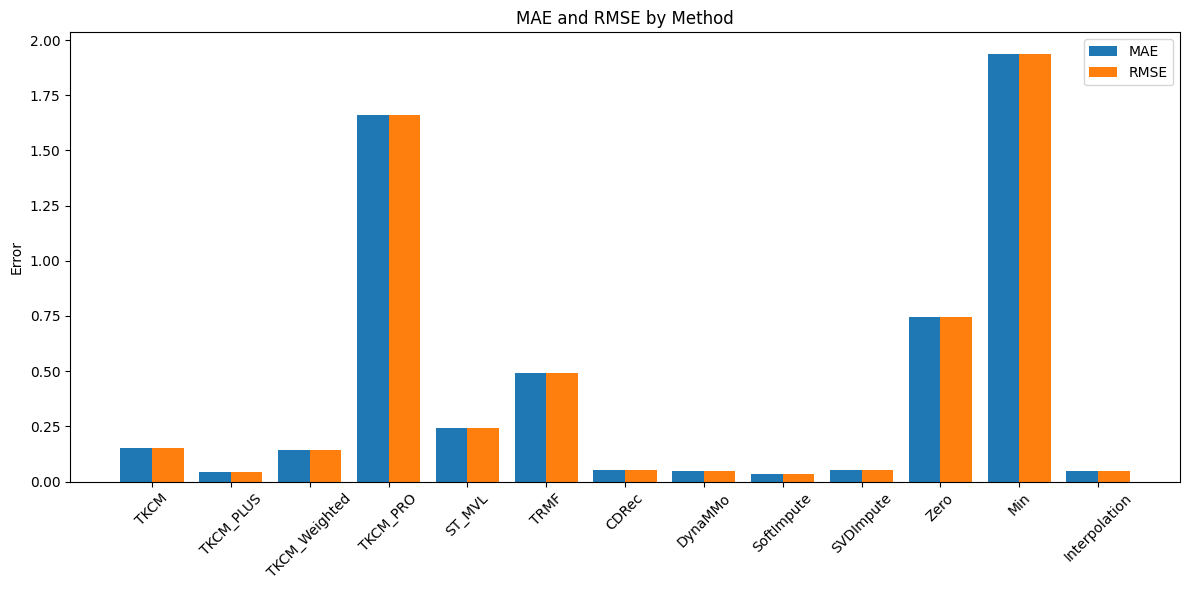

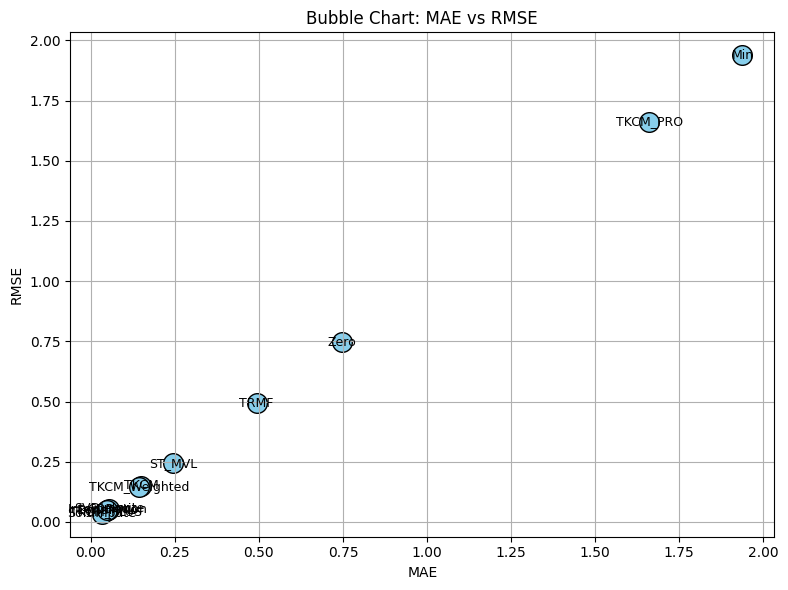

In [ ]:
# Convert results_point to DataFrame for plotting
results_df = pd.DataFrame(results_point)

# Filter out methods with valid numeric values
plot_df = results_df[(results_df["MAE"] != "NaN") & (results_df["RMSE"] != "NaN")].copy()
plot_df["MAE"] = plot_df["MAE"].astype(float)
plot_df["RMSE"] = plot_df["RMSE"].astype(float)

# ------------------------
# 📊 Bar Plot: MAE & RMSE
# ------------------------
fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.4
x = range(len(plot_df))

ax.bar([i - bar_width/2 for i in x], plot_df["MAE"], width=bar_width, label="MAE")
ax.bar([i + bar_width/2 for i in x], plot_df["RMSE"], width=bar_width, label="RMSE")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["Method"], rotation=45)
ax.set_ylabel("Error")
ax.set_title("MAE and RMSE by Method")
ax.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 🔵 Bubble Plot: MAE vs RMSE
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(plot_df["MAE"], plot_df["RMSE"],
                     s=200, c='skyblue', edgecolors='black')

# Annotate each point
for i, row in plot_df.iterrows():
    ax.annotate(row["Method"], (row["MAE"], row["RMSE"]), fontsize=9,
                ha='center', va='center')

ax.set_xlabel("MAE")
ax.set_ylabel("RMSE")
ax.set_title("Bubble Chart: MAE vs RMSE")
plt.grid(True)
plt.tight_layout()
plt.show()


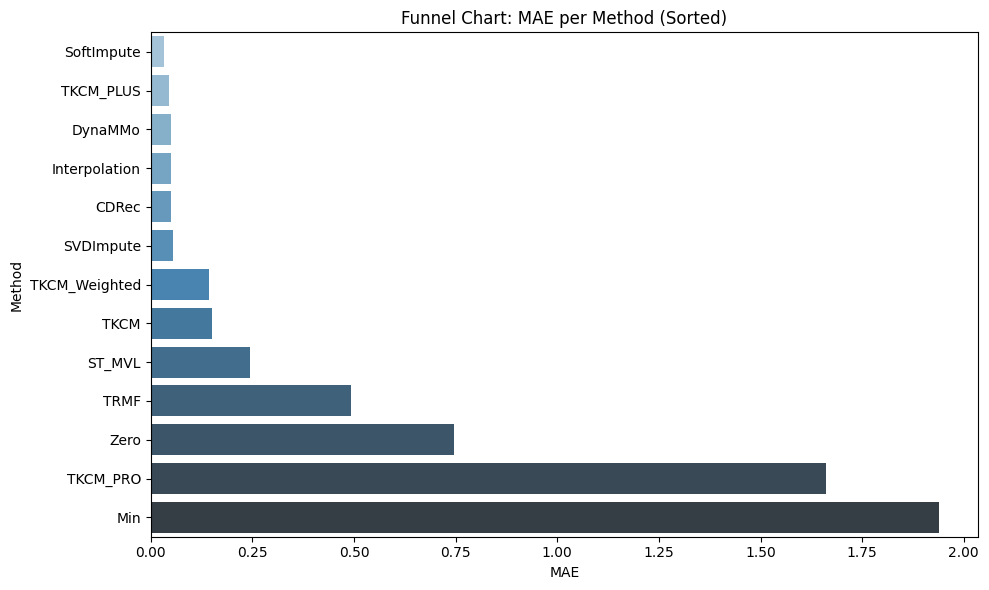

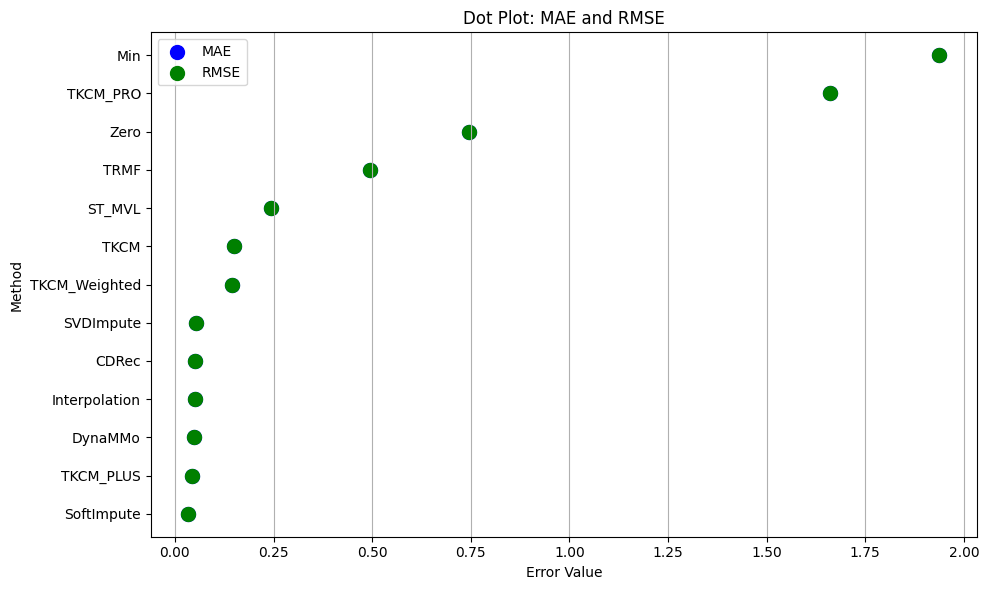

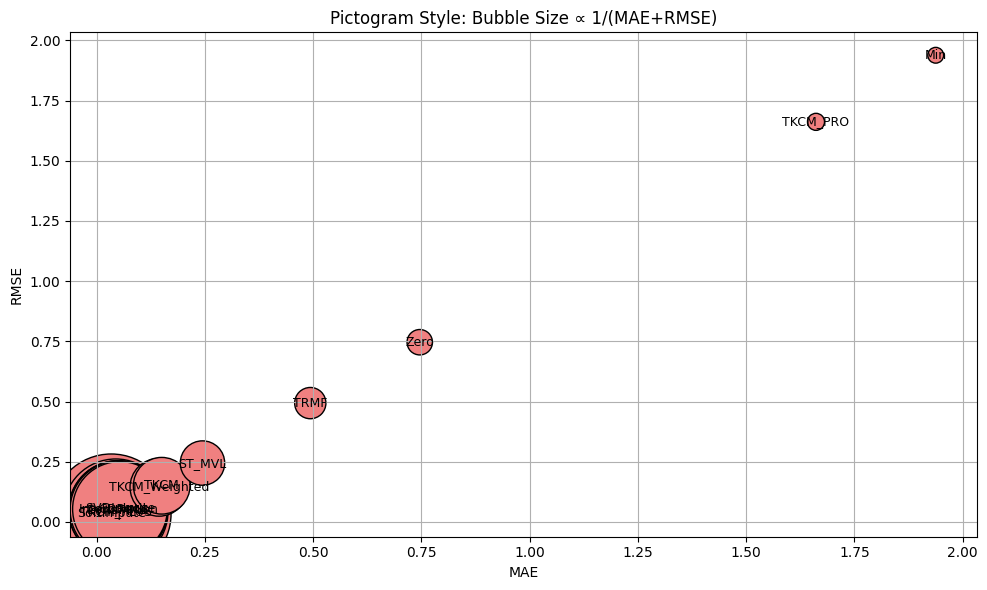

In [ ]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Use existing plot_df from previous context
plot_df = results_df[(results_df["MAE"] != "NaN") & (results_df["RMSE"] != "NaN")].copy()
plot_df["MAE"] = plot_df["MAE"].astype(float)
plot_df["RMSE"] = plot_df["RMSE"].astype(float)

# Sort by MAE for consistent plotting
plot_df = plot_df.sort_values("MAE").reset_index(drop=True)

# --------------------------------------
# 📉 Funnel Plot: Sorted MAE per Method
# --------------------------------------
plt.figure(figsize=(10, 6))
sns.barplot(x="MAE", y="Method", data=plot_df, palette="Blues_d")
plt.title("Funnel Chart: MAE per Method (Sorted)")
plt.xlabel("MAE")
plt.ylabel("Method")
plt.tight_layout()
plt.show()

# ------------------------------
# 🎯 Dot Plot: MAE & RMSE Values
# ------------------------------
plt.figure(figsize=(10, 6))
plt.scatter(plot_df["MAE"], plot_df["Method"], label="MAE", color="blue", s=100)
plt.scatter(plot_df["RMSE"], plot_df["Method"], label="RMSE", color="green", s=100)
plt.xlabel("Error Value")
plt.ylabel("Method")
plt.title("Dot Plot: MAE and RMSE")
plt.legend()
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()

# ---------------------------------
# 📦 Pictogram: Bubble-like Visual
# ---------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
sizes = 500 / (plot_df["MAE"] + plot_df["RMSE"])  # Inverse error = bigger is better

ax.scatter(plot_df["MAE"], plot_df["RMSE"], s=sizes, color='lightcoral', edgecolors='black')

for i, row in plot_df.iterrows():
    ax.annotate(row["Method"], (row["MAE"], row["RMSE"]), fontsize=9, ha='center', va='center')

ax.set_xlabel("MAE")
ax.set_ylabel("RMSE")
ax.set_title("Pictogram Style: Bubble Size ∝ 1/(MAE+RMSE)")
plt.grid(True)
plt.tight_layout()
plt.show()
